# 第133章: カメラ運動と物体運動の分離 — 3D-aware Video Generation

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] カメラ運動と物体運動の概念的分離を説明できる
- [ ] Plücker ray座標の数学的表現を理解し実装できる
- [ ] オプティカルフローの概念を理解し可視化できる
- [ ] 3Dワイヤーフレームオブジェクトの回転・投影をコードで合成できる
- [ ] 動画生成AIにおけるカメラ制御の仕組みを説明できる

## 🎯 前提知識

- ✅ Notebook 53（座標変換と剛体運動）
- ✅ Notebook 55（エピポーラ幾何の理論）
- ✅ Notebook 131（Video Diffusion Models）

⏱️ **推定学習時間**: 120-150分
📊 **難易度**: ★★★★☆（上級）
🎓 **カテゴリ**: 時空間モデリング / 3D-aware生成

## 目次

1. [なぜカメラと物体の運動分離が重要か](#section1)
2. [カメラ運動のパラメータ化](#section2)
3. [Plücker ray座標の理論](#section3)
4. [compute_plucker_rays の実装と可視化](#section4)
5. [generate_camera_motion_frames — カメラ軌道のシーン描画](#section5)
6. [オプティカルフロー概念と可視化](#section6)
7. [回転キューブのフレーム列合成](#section7)
8. [動画生成AIでの応用 — MotionCtrl / CameraCtrl](#section8)
9. [まとめと自己評価クイズ](#summary)

In [1]:
# ============================================================
# 環境設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
import torch
import warnings
import math

warnings.filterwarnings('ignore')

# --- 日本語フォント設定 ---
def setup_japanese_font():
    """日本語フォントを自動検出して設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# --- 再現性の確保 ---
torch.manual_seed(42)
np.random.seed(42)

# --- デバイス設定 ---
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')

print(f'✅ ライブラリのインポート完了')
print(f'🖥️ デバイス: {device}')
print(f'📝 日本語フォント: {font_used}')

✅ ライブラリのインポート完了
🖥️ デバイス: cpu
📝 日本語フォント: Yu Gothic


<a id="section1"></a>
## 1. なぜカメラと物体の運動分離が重要か

### 🤔 動画中の動きには2種類ある

現実世界の動画に映る「動き」は、実は2つの独立した要因から成り立っています：

| 運動の種類 | 原因 | 画像上の効果 | 例 |
|-----------|------|-------------|---|
| **カメラ運動** | カメラ自体が移動・回転する | 全画素が一貫して動く | パン、チルト、ドリー |
| **物体運動** | シーン内の物体が動く | 特定領域だけ動く | 歩行者、車、ボール |

動画生成AIにとって、この2種類の運動を **分離して制御** できることは非常に重要です。

### 📊 なぜ分離が必要か？

1. **ユーザー制御性**: 「カメラは固定で物体だけ動かす」「物体は静止でカメラだけ回す」を実現
2. **3D整合性**: カメラ運動は幾何学的法則に従うため、正確な3D構造を維持できる
3. **品質向上**: 混合された動きを一度に生成するより、分離した方が学習が容易

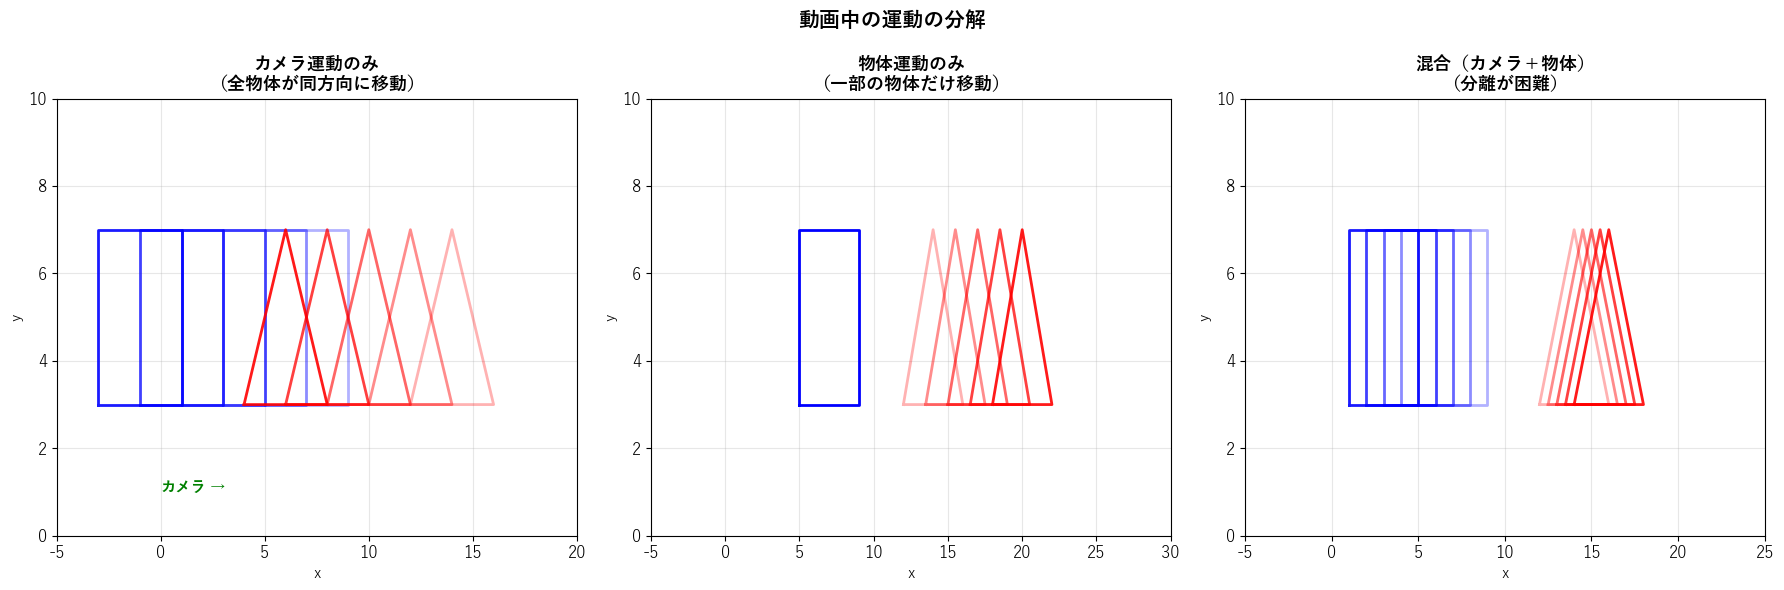

In [2]:
# ============================================================
# カメラ運動 vs 物体運動の概念図
# ============================================================

def visualize_motion_separation():
    """カメラ運動と物体運動の分離を図解する"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- 左: カメラ運動のみ ---
    ax = axes[0]
    # シーン内の静止物体（四角形と三角形）
    for t_idx in range(5):
        alpha = 0.3 + 0.15 * t_idx
        shift = t_idx * 2.0  # カメラが右に移動 → 物体は左にずれて見える
        # 四角形
        rect_x = np.array([5, 9, 9, 5, 5]) - shift
        rect_y = np.array([3, 3, 7, 7, 3])
        ax.plot(rect_x, rect_y, 'b-', alpha=alpha, linewidth=2)
        # 三角形
        tri_x = np.array([12, 16, 14, 12]) - shift
        tri_y = np.array([3, 3, 7, 3])
        ax.plot(tri_x, tri_y, 'r-', alpha=alpha, linewidth=2)
    ax.set_xlim(-5, 20)
    ax.set_ylim(0, 10)
    ax.set_title('カメラ運動のみ\n（全物体が同方向に移動）', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.annotate('カメラ →', xy=(0, 1), fontsize=11, color='green',
                fontweight='bold')
    ax.grid(True, alpha=0.3)

    # --- 中央: 物体運動のみ ---
    ax = axes[1]
    # 静止した四角形
    rect_x = np.array([5, 9, 9, 5, 5])
    rect_y = np.array([3, 3, 7, 7, 3])
    ax.plot(rect_x, rect_y, 'b-', linewidth=2, label='静止物体')
    # 移動する三角形
    for t_idx in range(5):
        alpha = 0.3 + 0.15 * t_idx
        shift = t_idx * 1.5
        tri_x = np.array([12, 16, 14, 12]) + shift
        tri_y = np.array([3, 3, 7, 3])
        ax.plot(tri_x, tri_y, 'r-', alpha=alpha, linewidth=2)
    ax.set_xlim(-5, 30)
    ax.set_ylim(0, 10)
    ax.set_title('物体運動のみ\n（一部の物体だけ移動）', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.grid(True, alpha=0.3)

    # --- 右: 混合 ---
    ax = axes[2]
    for t_idx in range(5):
        alpha = 0.3 + 0.15 * t_idx
        cam_shift = t_idx * 1.0
        obj_shift = t_idx * 1.5
        rect_x = np.array([5, 9, 9, 5, 5]) - cam_shift
        rect_y = np.array([3, 3, 7, 7, 3])
        ax.plot(rect_x, rect_y, 'b-', alpha=alpha, linewidth=2)
        tri_x = np.array([12, 16, 14, 12]) - cam_shift + obj_shift
        tri_y = np.array([3, 3, 7, 3])
        ax.plot(tri_x, tri_y, 'r-', alpha=alpha, linewidth=2)
    ax.set_xlim(-5, 25)
    ax.set_ylim(0, 10)
    ax.set_title('混合（カメラ＋物体）\n（分離が困難）', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.suptitle('動画中の運動の分解', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_motion_separation()

<a id="section2"></a>
## 2. カメラ運動のパラメータ化

### 📊 外部パラメータ：回転 + 並進

カメラの姿勢は **外部パラメータ（extrinsic parameters）** で表現されます。
Notebook 53で学んだ通り、これは回転行列 $R$ と並進ベクトル $\mathbf{t}$ の組です：

$$
[R | \mathbf{t}] = \begin{bmatrix}
r_{11} & r_{12} & r_{13} & t_x \\
r_{21} & r_{22} & r_{23} & t_y \\
r_{31} & r_{32} & r_{33} & t_z
\end{bmatrix}
$$

### カメラ運動の6自由度

| パラメータ | 自由度 | 説明 |
|-----------|--------|------|
| 並進 (Translation) | 3 | $t_x, t_y, t_z$ — カメラ位置の移動 |
| 回転 (Rotation) | 3 | roll, pitch, yaw — カメラの向きの変化 |

### 典型的なカメラ運動パターン

| 運動名 | 説明 | パラメータ変化 |
|--------|------|---------------|
| **パン (Pan)** | 水平回転 | yaw が変化 |
| **チルト (Tilt)** | 垂直回転 | pitch が変化 |
| **ドリー (Dolly)** | 前後移動 | $t_z$ が変化 |
| **トラック (Track)** | 左右移動 | $t_x$ が変化 |
| **ペデスタル (Pedestal)** | 上下移動 | $t_y$ が変化 |
| **オービット (Orbit)** | 被写体周りの周回 | 位置と向きが同時に変化 |

In [3]:
# ============================================================
# カメラ運動のパラメータ化 — 回転行列の生成
# ============================================================

def rotation_matrix_x(theta):
    """X軸周りの回転行列（ピッチ）
    
    Args:
        theta: 回転角度 (ラジアン)
    Returns:
        (3, 3) の回転行列 (numpy)
    """
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1,  0, 0],
        [0,  c, -s],
        [0,  s,  c]
    ])

def rotation_matrix_y(theta):
    """Y軸周りの回転行列（ヨー）"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])

def rotation_matrix_z(theta):
    """Z軸周りの回転行列（ロール）"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

def look_at_matrix(camera_pos, target, up=np.array([0, 1, 0])):
    """Look-at行列を生成する
    
    カメラ位置と注視点から外部パラメータ行列を構築する。
    
    Args:
        camera_pos: (3,) カメラ位置
        target: (3,) 注視点
        up: (3,) 上方向ベクトル
    Returns:
        R: (3, 3) 回転行列
        t: (3,) 並進ベクトル
    """
    # カメラのZ軸（前方向、カメラからターゲットへ）
    forward = target - camera_pos
    forward = forward / np.linalg.norm(forward)
    
    # カメラのX軸（右方向）
    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    
    # カメラのY軸（上方向、再計算）
    new_up = np.cross(right, forward)
    
    # 回転行列（ワールド → カメラ座標系）
    R = np.array([right, new_up, -forward])
    t = -R @ camera_pos
    
    return R, t

# --- テスト: 軌道カメラの姿勢を計算 ---
print("="*60)
print("カメラ運動のパラメータ化")
print("="*60)

# 原点を見ながら周回するカメラ
angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
radius = 5.0

print(f"\n軌道半径: {radius}, フレーム数: {len(angles)}")
print(f"{'角度':>8s}  {'カメラ位置':>30s}  {'並進ベクトル':>30s}")
print("-" * 75)

for i, angle in enumerate(angles):
    cam_pos = np.array([radius * np.cos(angle), 0, radius * np.sin(angle)])
    R, t = look_at_matrix(cam_pos, np.array([0, 0, 0]))
    print(f"{np.degrees(angle):7.1f}°  ({cam_pos[0]:6.2f}, {cam_pos[1]:6.2f}, {cam_pos[2]:6.2f})  "
          f"({t[0]:6.2f}, {t[1]:6.2f}, {t[2]:6.2f})")

print("\n✅ Look-at行列の生成を確認")

カメラ運動のパラメータ化

軌道半径: 5.0, フレーム数: 8
      角度                           カメラ位置                          並進ベクトル
---------------------------------------------------------------------------
    0.0°  (  5.00,   0.00,   0.00)  (  0.00,   0.00,  -5.00)
   45.0°  (  3.54,   0.00,   3.54)  ( -0.00,   0.00,  -5.00)
   90.0°  (  0.00,   0.00,   5.00)  ( -0.00,   0.00,  -5.00)
  135.0°  ( -3.54,   0.00,   3.54)  (  0.00,   0.00,  -5.00)
  180.0°  ( -5.00,   0.00,   0.00)  (  0.00,   0.00,  -5.00)
  225.0°  ( -3.54,   0.00,  -3.54)  ( -0.00,   0.00,  -5.00)
  270.0°  ( -0.00,   0.00,  -5.00)  (  0.00,   0.00,  -5.00)
  315.0°  (  3.54,   0.00,  -3.54)  ( -0.00,   0.00,  -5.00)

✅ Look-at行列の生成を確認


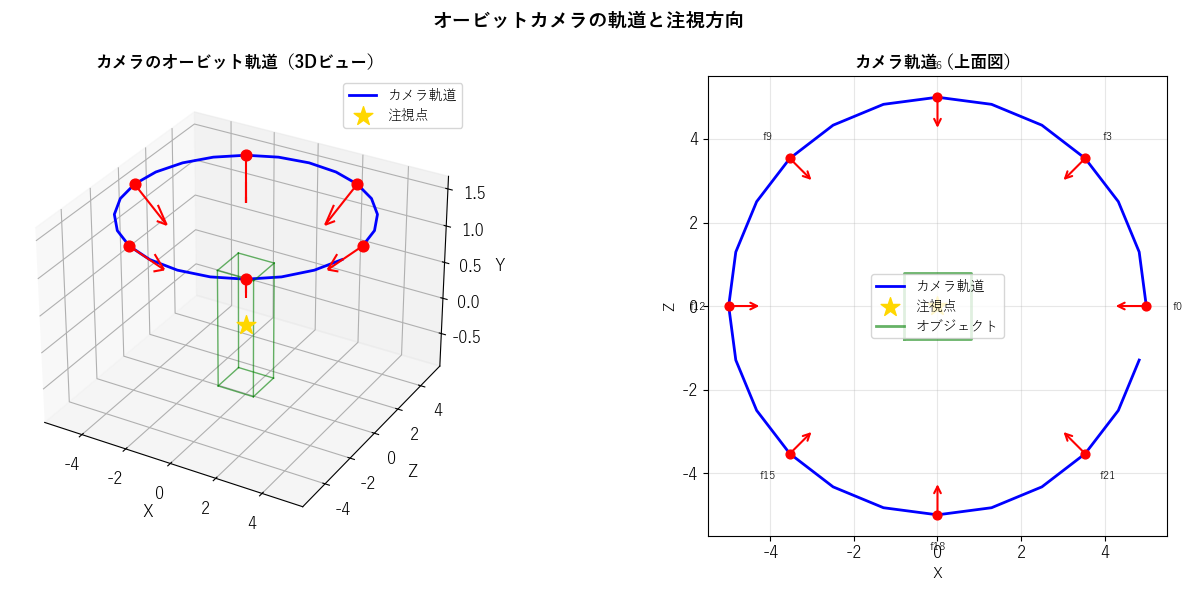

In [4]:
# ============================================================
# カメラ軌道の3D可視化
# ============================================================

def visualize_camera_orbit():
    """カメラのオービット軌道を3Dで可視化する"""
    fig = plt.figure(figsize=(14, 6))
    
    # --- 左: 3Dビュー ---
    ax1 = fig.add_subplot(121, projection='3d')
    
    # カメラ軌道
    num_frames = 24
    angles = np.linspace(0, 2 * np.pi, num_frames, endpoint=False)
    radius = 5.0
    cam_positions = []
    
    for i, angle in enumerate(angles):
        cx = radius * np.cos(angle)
        cz = radius * np.sin(angle)
        cy = 1.5  # 少し上から見下ろす
        cam_positions.append([cx, cy, cz])
    
    cam_positions = np.array(cam_positions)
    
    # 軌道を描画
    ax1.plot(cam_positions[:, 0], cam_positions[:, 2], cam_positions[:, 1],
             'b-', linewidth=2, label='カメラ軌道')
    
    # カメラ位置にマーカー
    for i in range(0, num_frames, 4):
        ax1.scatter(*cam_positions[i, [0, 2, 1]], c='red', s=60, zorder=5)
        # カメラの向き（原点に向かう矢印）
        direction = -cam_positions[i] / np.linalg.norm(cam_positions[i]) * 1.5
        ax1.quiver(cam_positions[i, 0], cam_positions[i, 2], cam_positions[i, 1],
                   direction[0], direction[2], direction[1],
                   color='red', arrow_length_ratio=0.3, linewidth=1.5)
    
    # 注視点（原点）
    ax1.scatter(0, 0, 0, c='gold', s=200, marker='*', label='注視点', zorder=5)
    
    # シーン内のオブジェクト（単純な箱）
    box_verts = np.array([
        [-1, -1, -1], [1, -1, -1], [1, -1, 1], [-1, -1, 1],
        [-1,  1, -1], [1,  1, -1], [1,  1, 1], [-1,  1, 1]
    ]) * 0.8
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    for e in edges:
        ax1.plot(*zip(box_verts[e[0], [0,2,1]], box_verts[e[1], [0,2,1]]),
                'g-', linewidth=1, alpha=0.6)
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Z')
    ax1.set_zlabel('Y')
    ax1.set_title('カメラのオービット軌道（3Dビュー）', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    
    # --- 右: 上面図 ---
    ax2 = fig.add_subplot(122)
    
    # 軌道
    ax2.plot(cam_positions[:, 0], cam_positions[:, 2], 'b-', linewidth=2, label='カメラ軌道')
    
    # カメラ位置と向き
    for i in range(0, num_frames, 3):
        ax2.scatter(cam_positions[i, 0], cam_positions[i, 2], c='red', s=40, zorder=5)
        direction = -cam_positions[i, [0, 2]] / np.linalg.norm(cam_positions[i, [0, 2]]) * 0.8
        ax2.annotate('', xy=(cam_positions[i, 0] + direction[0],
                            cam_positions[i, 2] + direction[1]),
                    xytext=(cam_positions[i, 0], cam_positions[i, 2]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        ax2.text(cam_positions[i, 0] * 1.15, cam_positions[i, 2] * 1.15,
                f'f{i}', fontsize=8, ha='center', va='center')
    
    # 注視点
    ax2.scatter(0, 0, c='gold', s=200, marker='*', zorder=5, label='注視点')
    
    # 箱（上面図）
    box_top = np.array([[-0.8, -0.8], [0.8, -0.8], [0.8, 0.8], [-0.8, 0.8], [-0.8, -0.8]])
    ax2.plot(box_top[:, 0], box_top[:, 1], 'g-', linewidth=2, alpha=0.6, label='オブジェクト')
    
    ax2.set_xlabel('X', fontsize=11)
    ax2.set_ylabel('Z', fontsize=11)
    ax2.set_title('カメラ軌道（上面図）', fontsize=12, fontweight='bold')
    ax2.set_aspect('equal')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('オービットカメラの軌道と注視方向', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_camera_orbit()

<a id="section3"></a>
## 3. Plücker ray座標の理論

### 📊 なぜPlücker座標が必要か？

3D-aware動画生成では、各ピクセルに対応する **レイ（光線）** を数学的に表現する必要があります。
Notebook 61で学んだレイキャスティングの拡張として、Plücker座標は特に有用です。

### Plücker座標の定義

3D空間中の直線（レイ）は、Plücker座標で6次元ベクトルとして表現されます：

$$
\mathbf{p} = (\mathbf{d}, \mathbf{m}) \in \mathbb{R}^6
$$

- $\mathbf{d}$: レイの**方向ベクトル**（direction）
- $\mathbf{m} = \mathbf{o} \times \mathbf{d}$: レイの**モーメント**（moment）

ここで $\mathbf{o}$ はレイの始点（カメラ位置）です。

### なぜ $(\mathbf{o} \times \mathbf{d}, \mathbf{d})$ なのか？

1. **一意性**: 始点 $\mathbf{o}$ を直接使うと、同一直線上の異なる点で異なる表現になる。
   モーメント $\mathbf{m} = \mathbf{o} \times \mathbf{d}$ は直線上のどの点を選んでも同じ値になる
2. **幾何学的意味**: $\|\mathbf{m}\| / \|\mathbf{d}\|$ は原点から直線への距離
3. **動画生成での利用**: CameraCtrlなどの手法では、Plücker座標をU-Netの条件入力として使用

### Plücker座標の性質

| 性質 | 説明 |
|------|------|
| 次元 | 6次元 $(m_x, m_y, m_z, d_x, d_y, d_z)$ |
| 不変性 | 直線上のどの点を始点としても同じモーメント |
| Grassmann条件 | $\mathbf{d} \cdot \mathbf{m} = 0$（方向とモーメントは直交）|

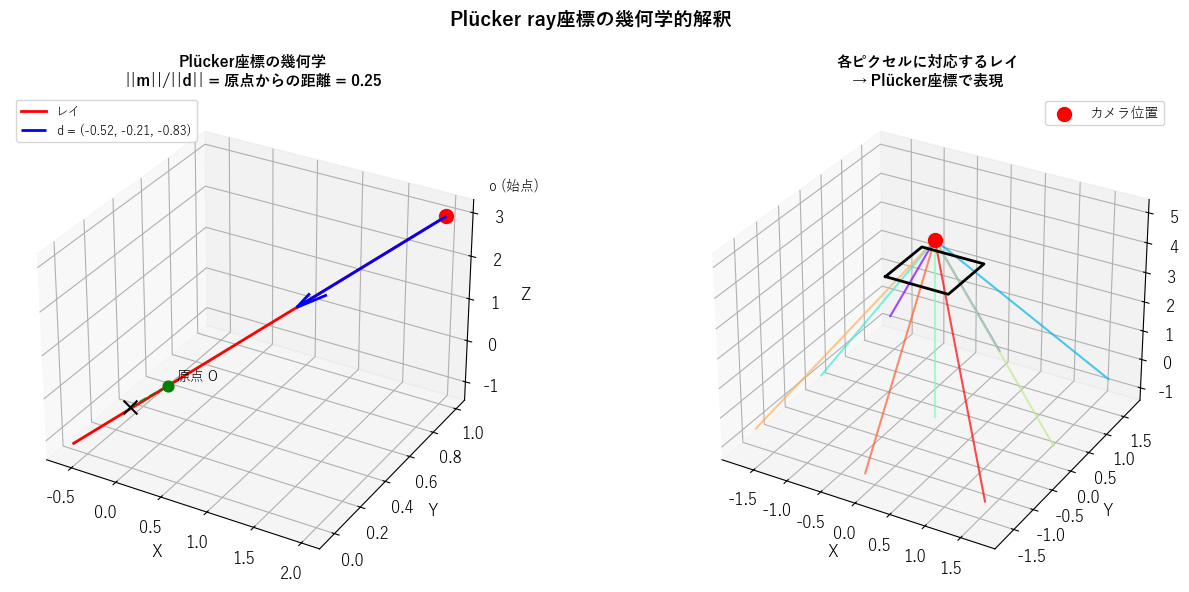

Grassmann条件の検証: d · m = 0
  d = [-0.51847585 -0.20739034 -0.82956136]
  m = o × d = [-0.20739034  0.10369517  0.10369517]
  d · m = -0.0000000000 (≈ 0 ✅)


In [5]:
# ============================================================
# Plücker座標の幾何学的意味の可視化
# ============================================================

def visualize_plucker_geometry():
    """Plücker座標の幾何学的意味を図示する"""
    fig = plt.figure(figsize=(14, 6))
    
    # --- 左: 単一レイのPlücker座標 ---
    ax1 = fig.add_subplot(121, projection='3d')
    
    # カメラ位置（レイの始点）
    origin = np.array([2, 1, 3])
    # レイの方向
    direction = np.array([-0.5, -0.2, -0.8])
    direction = direction / np.linalg.norm(direction)
    
    # モーメント: m = o × d
    moment = np.cross(origin, direction)
    
    # レイを描画
    ray_end = origin + direction * 5
    ax1.plot(*zip(origin, ray_end), 'r-', linewidth=2, label='レイ')
    ax1.scatter(*origin, c='red', s=100, zorder=5)
    ax1.text(origin[0]+0.2, origin[1]+0.2, origin[2]+0.2, 'o (始点)', fontsize=10)
    
    # 方向ベクトル
    ax1.quiver(*origin, *direction*2, color='blue', arrow_length_ratio=0.15,
              linewidth=2, label=f'd = ({direction[0]:.2f}, {direction[1]:.2f}, {direction[2]:.2f})')
    
    # 原点
    ax1.scatter(0, 0, 0, c='black', s=100, marker='x', zorder=5)
    ax1.text(0.2, 0.2, 0.2, '原点 O', fontsize=10)
    
    # 原点からレイへの最短距離を表示
    # 最近点: o + t*d where t = -o·d
    t_closest = -np.dot(origin, direction)
    closest_point = origin + t_closest * direction
    ax1.plot(*zip([0,0,0], closest_point), 'g--', linewidth=1.5, alpha=0.7)
    ax1.scatter(*closest_point, c='green', s=60, zorder=5)
    
    dist = np.linalg.norm(moment) / np.linalg.norm(direction)
    ax1.set_title(f'Plücker座標の幾何学\n||m||/||d|| = 原点からの距離 = {dist:.2f}',
                 fontsize=11, fontweight='bold')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend(fontsize=9, loc='upper left')
    
    # --- 右: 複数レイ（ピクセル対応） ---
    ax2 = fig.add_subplot(122, projection='3d')
    
    cam_pos = np.array([0, 0, 5])
    
    # 3x3ピクセルグリッドのレイ
    colors_map = plt.cm.rainbow(np.linspace(0, 1, 9))
    idx = 0
    for i in range(3):
        for j in range(3):
            # ピクセル位置から方向を計算
            px = (j - 1) * 0.3
            py = (1 - i) * 0.3
            d = np.array([px, py, -1.0])
            d = d / np.linalg.norm(d)
            
            ray_end = cam_pos + d * 6
            ax2.plot(*zip(cam_pos, ray_end), '-', color=colors_map[idx],
                    linewidth=1.5, alpha=0.7)
            idx += 1
    
    ax2.scatter(*cam_pos, c='red', s=100, zorder=5, label='カメラ位置')
    
    # 画像平面を表示
    plane_corners = np.array([
        [-0.45, -0.45, 4.0],
        [ 0.45, -0.45, 4.0],
        [ 0.45,  0.45, 4.0],
        [-0.45,  0.45, 4.0],
        [-0.45, -0.45, 4.0],
    ])
    ax2.plot(plane_corners[:, 0], plane_corners[:, 1], plane_corners[:, 2],
            'k-', linewidth=2)
    
    ax2.set_title('各ピクセルに対応するレイ\n→ Plücker座標で表現', fontsize=11, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.legend(fontsize=10)
    
    plt.suptitle('Plücker ray座標の幾何学的解釈', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 検算: Grassmann条件 d · m = 0
    print("Grassmann条件の検証: d · m = 0")
    print(f"  d = {direction}")
    print(f"  m = o × d = {moment}")
    print(f"  d · m = {np.dot(direction, moment):.10f} (≈ 0 ✅)")

visualize_plucker_geometry()

<a id="section4"></a>
## 4. compute_plucker_rays の実装と可視化

### 📊 実装の流れ

1. カメラ位置と注視点からカメラ座標系を構築
2. 画像ピクセルごとにレイ方向を計算
3. Plücker座標 $(\mathbf{o} \times \mathbf{d}, \mathbf{d})$ を返す

返り値は `(H, W, 6)` テンソルで、各ピクセルのPlücker座標を格納します。

In [6]:
# ============================================================
# compute_plucker_rays の実装
# ============================================================

def compute_plucker_rays(camera_pos, look_at, image_size, fov=60.0):
    """各ピクセルのPlücker ray座標を計算する
    
    Args:
        camera_pos: (3,) カメラのワールド座標位置
        look_at: (3,) 注視点のワールド座標
        image_size: (H, W) 画像サイズ
        fov: 水平画角（度）
    
    Returns:
        plucker: (H, W, 6) テンソル
                 前半3チャンネル: moment (o × d)
                 後半3チャンネル: direction (d)
    """
    camera_pos = np.asarray(camera_pos, dtype=np.float64)
    look_at = np.asarray(look_at, dtype=np.float64)
    H, W = image_size
    
    # --- Step 1: カメラ座標系の構築 ---
    up = np.array([0.0, 1.0, 0.0])
    
    # 前方向（カメラ → ターゲット）
    forward = look_at - camera_pos
    forward = forward / np.linalg.norm(forward)
    
    # 右方向
    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    
    # 上方向（再計算で正規直交系を保証）
    cam_up = np.cross(right, forward)
    
    # --- Step 2: ピクセルごとのレイ方向 ---
    # 焦点距離（ピクセル単位）
    fov_rad = np.radians(fov)
    focal_length = (W / 2.0) / np.tan(fov_rad / 2.0)
    
    # ピクセルグリッド（画像中心を原点に）
    u = np.arange(W) - (W - 1) / 2.0  # 横方向
    v = np.arange(H) - (H - 1) / 2.0  # 縦方向
    uu, vv = np.meshgrid(u, v)  # (H, W)
    
    # カメラ座標系でのレイ方向
    #   x: 右方向(u), y: 上方向(-v, 画像座標は下向き), z: 前方向(f)
    rays_cam_x = uu           # (H, W)
    rays_cam_y = -vv          # (H, W) 画像のy軸は下向きなので反転
    rays_cam_z = np.full_like(uu, focal_length)  # (H, W)
    
    # ワールド座標系に変換
    # direction = x * right + y * cam_up + z * forward
    directions = (rays_cam_x[..., None] * right[None, None, :] +
                  rays_cam_y[..., None] * cam_up[None, None, :] +
                  rays_cam_z[..., None] * forward[None, None, :])  # (H, W, 3)
    
    # 正規化
    norms = np.linalg.norm(directions, axis=-1, keepdims=True)
    directions = directions / norms  # (H, W, 3)
    
    # --- Step 3: Plücker座標の計算 ---
    # moment = origin × direction（各ピクセルごと）
    origin_broadcast = camera_pos[None, None, :]  # (1, 1, 3)
    moments = np.cross(
        np.broadcast_to(origin_broadcast, (H, W, 3)),
        directions
    )  # (H, W, 3)
    
    # Plücker座標: (moment, direction) を結合
    plucker = np.concatenate([moments, directions], axis=-1)  # (H, W, 6)
    
    return plucker

# --- テスト ---
cam_pos = np.array([0.0, 0.0, 5.0])
target = np.array([0.0, 0.0, 0.0])
image_size = (64, 64)
fov = 60.0

plucker_rays = compute_plucker_rays(cam_pos, target, image_size, fov)

print("="*60)
print("compute_plucker_rays テスト")
print("="*60)
print(f"カメラ位置: {cam_pos}")
print(f"注視点: {target}")
print(f"画像サイズ: {image_size}")
print(f"画角: {fov}°")
print(f"出力形状: {plucker_rays.shape}")
print(f"Moment (中心ピクセル): {plucker_rays[32, 32, :3]}")
print(f"Direction (中心ピクセル): {plucker_rays[32, 32, 3:]}")

# Grassmann条件の検証
d = plucker_rays[:, :, 3:]
m = plucker_rays[:, :, :3]
dot_product = np.sum(d * m, axis=-1)
print(f"\nGrassmann条件 d·m ≈ 0:")
print(f"  最大値: {np.abs(dot_product).max():.2e}")
print(f"  平均値: {np.abs(dot_product).mean():.2e}")
print("✅ 全ピクセルでGrassmann条件が満たされている")

compute_plucker_rays テスト
カメラ位置: [0. 0. 5.]
注視点: [0. 0. 0.]
画像サイズ: (64, 64)
画角: 60.0°
出力形状: (64, 64, 6)
Moment (中心ピクセル): [ 0.04510182  0.04510182 -0.        ]
Direction (中心ピクセル): [ 0.00902036 -0.00902036 -0.99991863]

Grassmann条件 d·m ≈ 0:
  最大値: 1.11e-16
  平均値: 1.76e-17
✅ 全ピクセルでGrassmann条件が満たされている


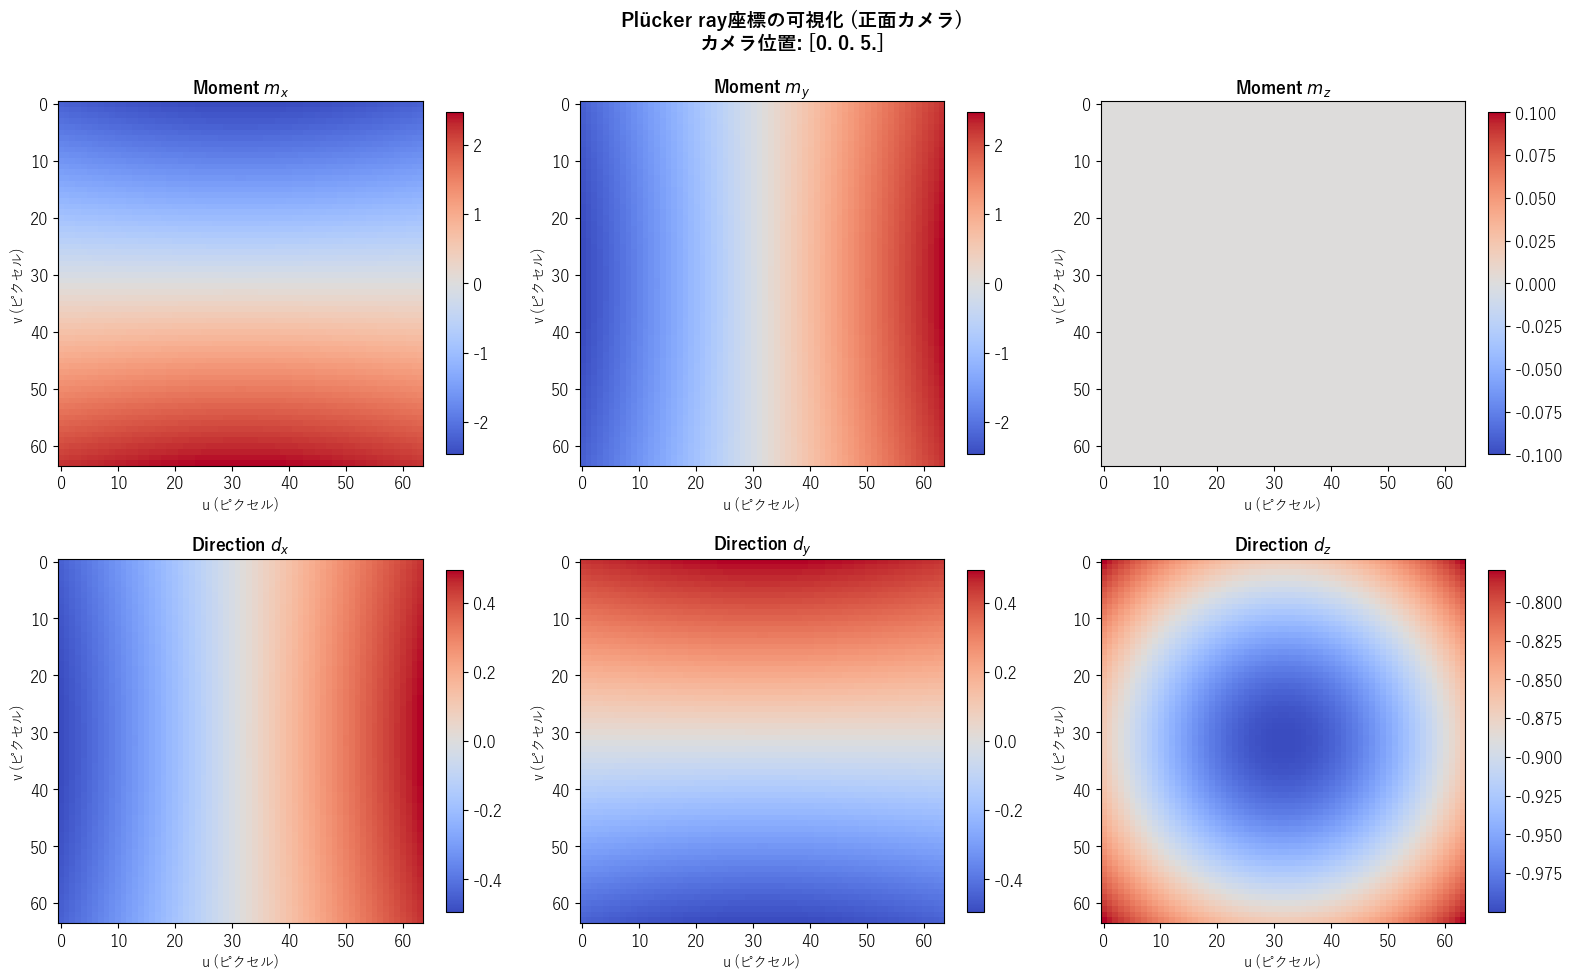

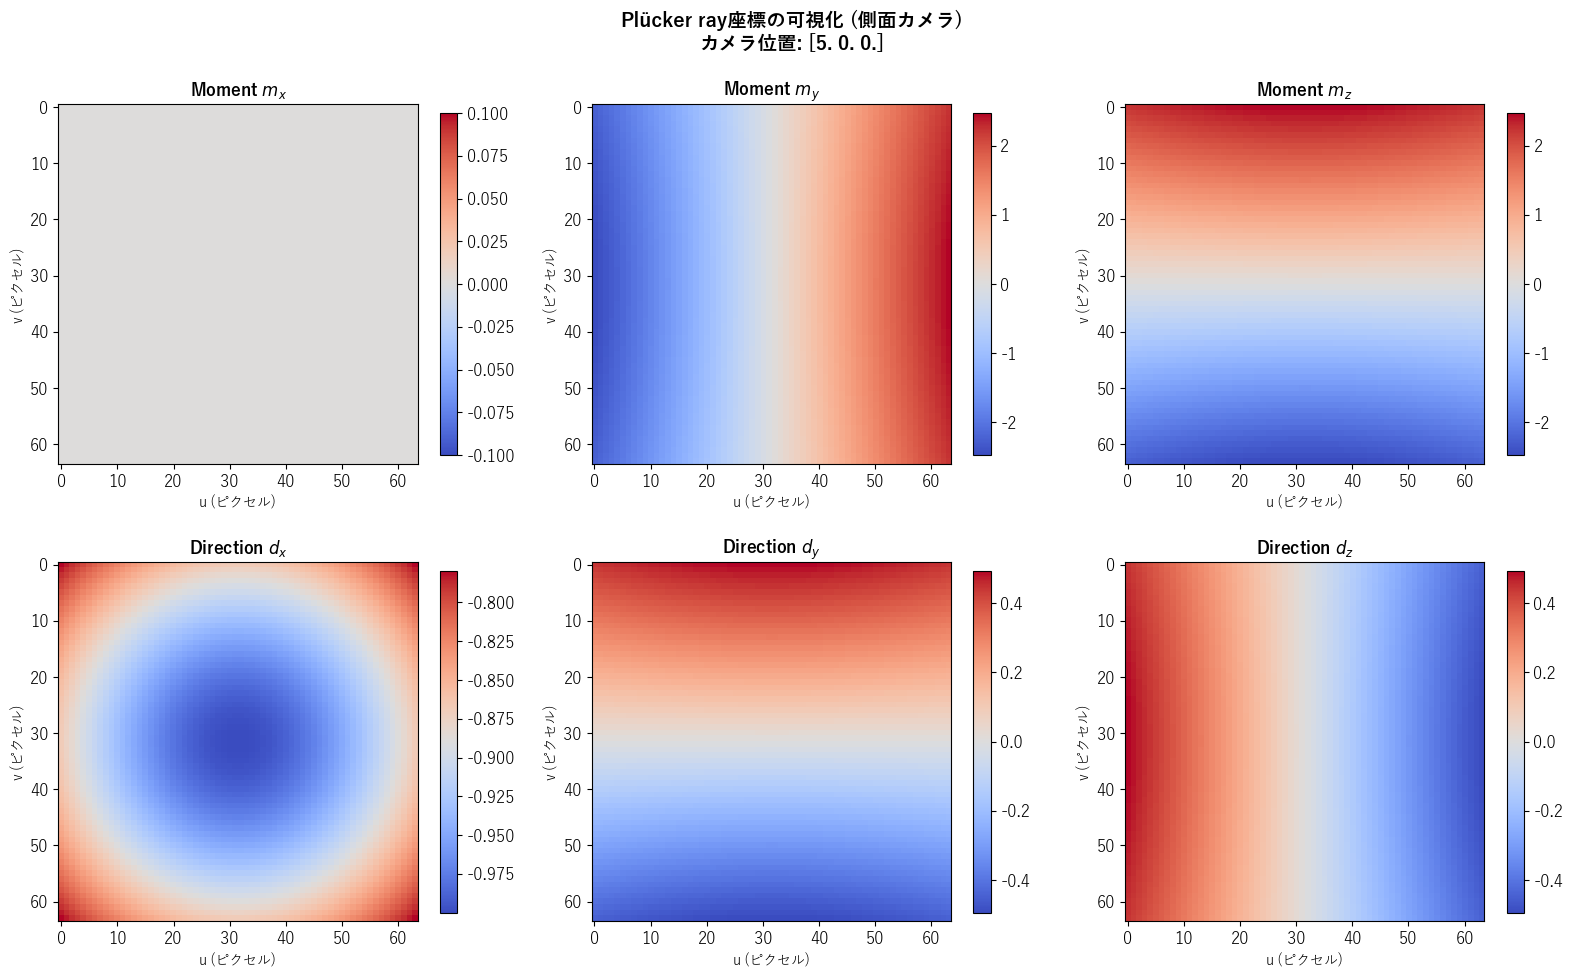


観察ポイント:
- Direction成分: カメラの向きに依存した滑らかなグラデーション
- Moment成分: カメラ位置と方向の外積 → 位置情報をエンコード
- カメラ位置が変わるとモーメント成分のパターンが大きく変化する


In [7]:
# ============================================================
# Plücker rayの可視化
# ============================================================

def visualize_plucker_rays(plucker_rays, camera_pos, title_suffix=""):
    """Plücker rayの各チャンネルを画像として可視化"""
    H, W, _ = plucker_rays.shape
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    channel_names = [
        'Moment $m_x$', 'Moment $m_y$', 'Moment $m_z$',
        'Direction $d_x$', 'Direction $d_y$', 'Direction $d_z$'
    ]
    
    for i in range(6):
        row, col = i // 3, i % 3
        ax = axes[row, col]
        data = plucker_rays[:, :, i]
        im = ax.imshow(data, cmap='coolwarm', aspect='equal')
        ax.set_title(channel_names[i], fontsize=12, fontweight='bold')
        ax.set_xlabel('u (ピクセル)', fontsize=10)
        ax.set_ylabel('v (ピクセル)', fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.suptitle(f'Plücker ray座標の可視化{title_suffix}\n'
                f'カメラ位置: {camera_pos}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# メインカメラからのPlücker ray
visualize_plucker_rays(plucker_rays, cam_pos, " (正面カメラ)")

# 横からのカメラ
cam_pos_side = np.array([5.0, 0.0, 0.0])
plucker_side = compute_plucker_rays(cam_pos_side, target, image_size, fov)
visualize_plucker_rays(plucker_side, cam_pos_side, " (側面カメラ)")

print("\n観察ポイント:")
print("- Direction成分: カメラの向きに依存した滑らかなグラデーション")
print("- Moment成分: カメラ位置と方向の外積 → 位置情報をエンコード")
print("- カメラ位置が変わるとモーメント成分のパターンが大きく変化する")

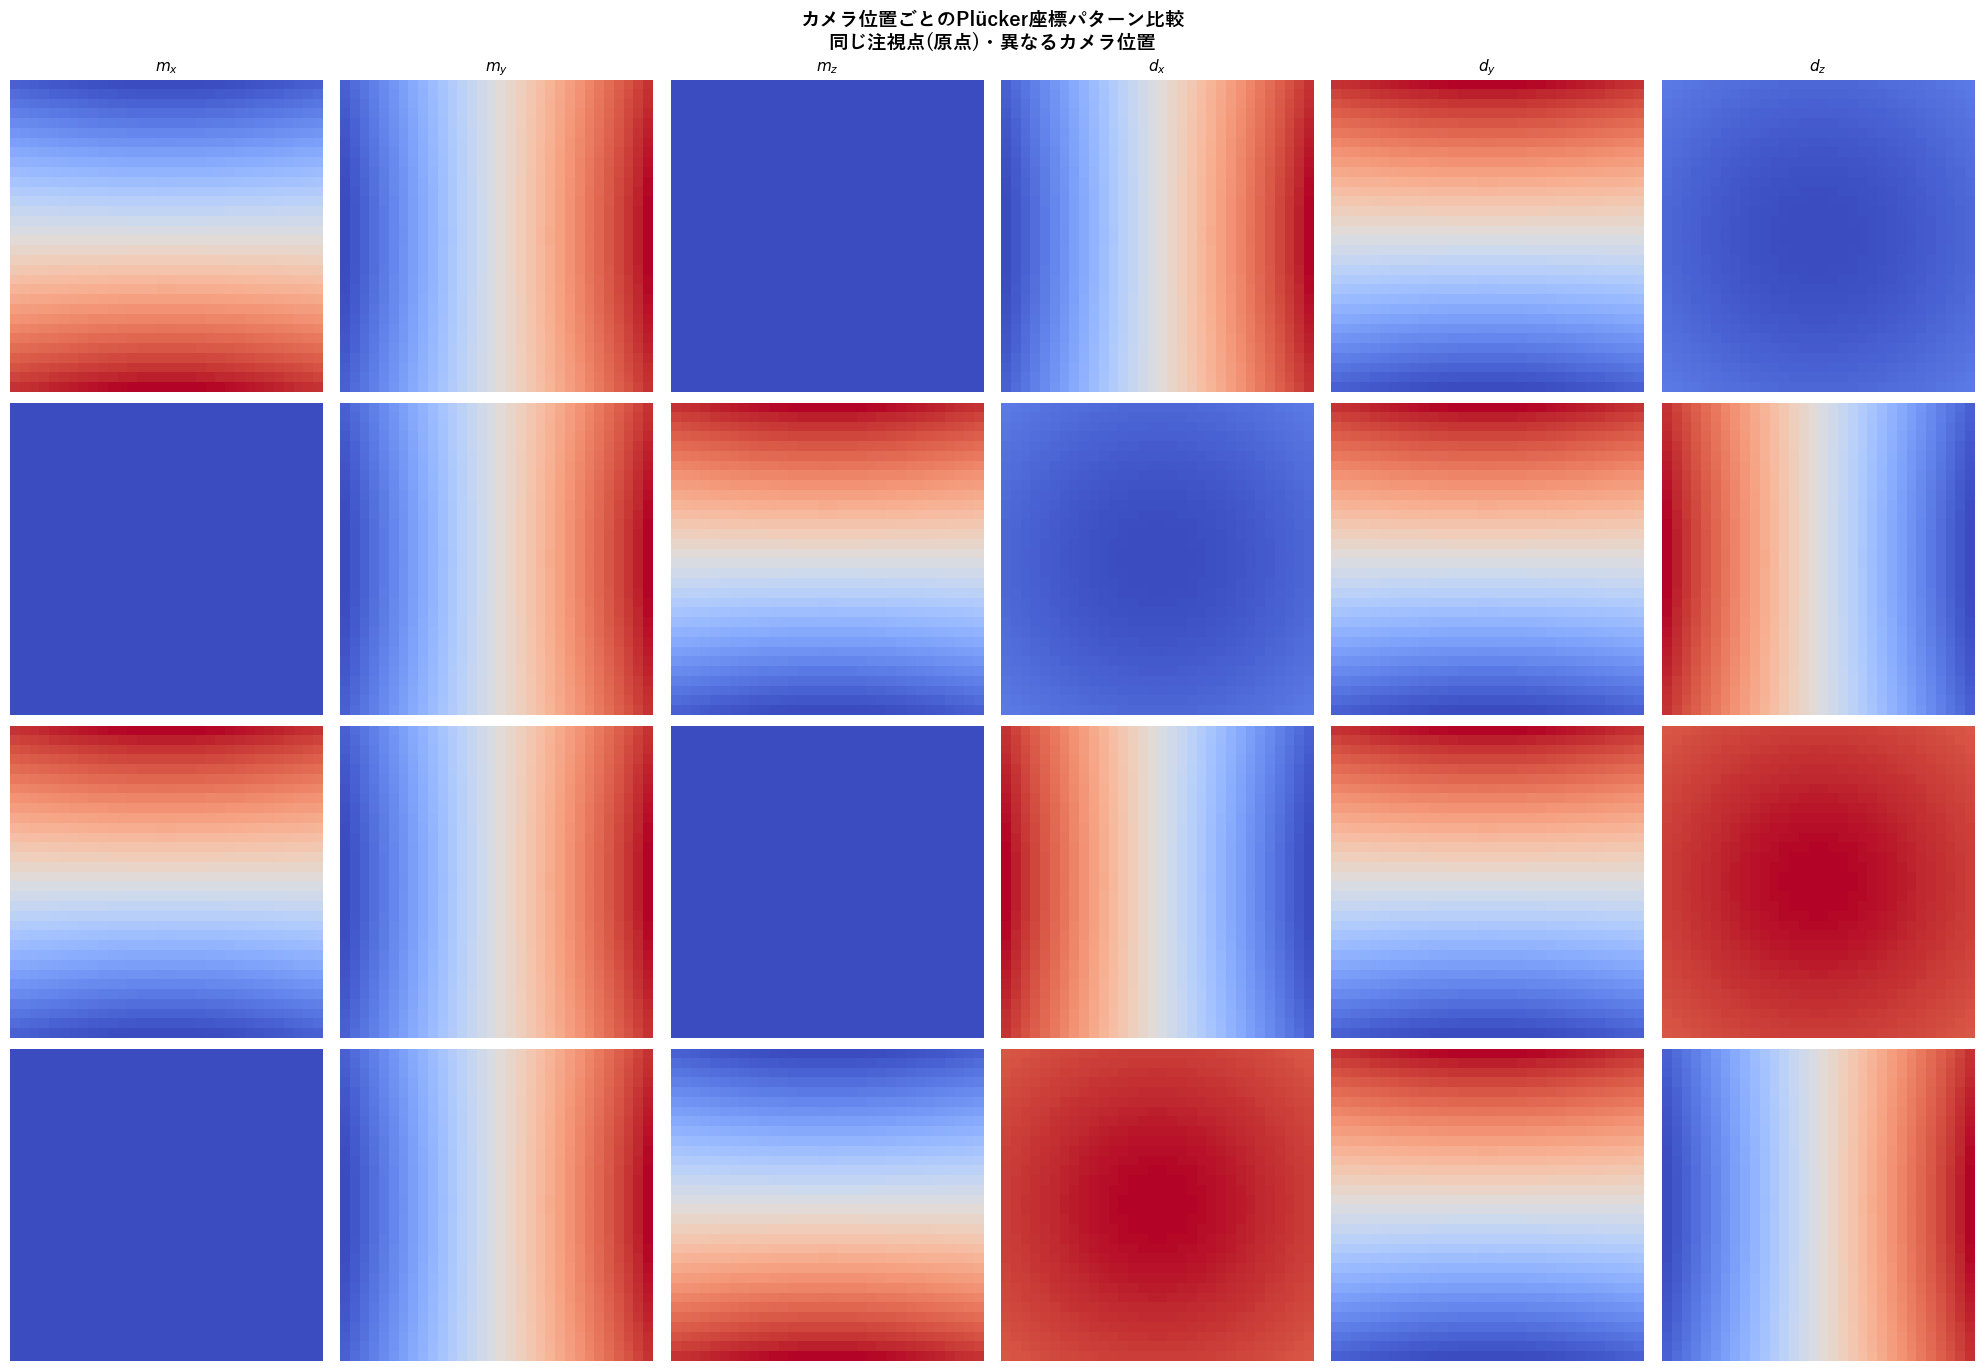

重要な観察:
- 方向成分(d)はカメラの向きに応じて回転する
- モーメント成分(m)はカメラ位置の情報を持つため、パターンが大きく変化
- この6次元表現により、ニューラルネットがカメラ姿勢を正確に条件付けできる


In [8]:
# ============================================================
# 異なるカメラ位置でのPlücker rayの比較
# ============================================================

def compare_plucker_cameras():
    """複数のカメラ位置からのPlücker rayの差異を可視化"""
    target = np.array([0.0, 0.0, 0.0])
    img_size = (32, 32)
    fov = 60.0
    
    # 4つのカメラ位置（前、右、後、左）
    camera_configs = [
        (np.array([0, 0,  5]), '正面 (0°)'),
        (np.array([5, 0,  0]), '右 (90°)'),
        (np.array([0, 0, -5]), '背面 (180°)'),
        (np.array([-5, 0, 0]), '左 (270°)'),
    ]
    
    fig, axes = plt.subplots(4, 6, figsize=(20, 14))
    
    channel_names = ['$m_x$', '$m_y$', '$m_z$', '$d_x$', '$d_y$', '$d_z$']
    
    for row, (cam_pos, label) in enumerate(camera_configs):
        plucker = compute_plucker_rays(cam_pos, target, img_size, fov)
        
        for col in range(6):
            ax = axes[row, col]
            data = plucker[:, :, col]
            vmax = max(abs(data.min()), abs(data.max()))
            im = ax.imshow(data, cmap='coolwarm', vmin=-vmax, vmax=vmax, aspect='equal')
            if row == 0:
                ax.set_title(channel_names[col], fontsize=11, fontweight='bold')
            ax.axis('off')
        
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0,
                                labelpad=60, va='center')
    
    plt.suptitle('カメラ位置ごとのPlücker座標パターン比較\n'
                '同じ注視点(原点)・異なるカメラ位置',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("重要な観察:")
    print("- 方向成分(d)はカメラの向きに応じて回転する")
    print("- モーメント成分(m)はカメラ位置の情報を持つため、パターンが大きく変化")
    print("- この6次元表現により、ニューラルネットがカメラ姿勢を正確に条件付けできる")

compare_plucker_cameras()

<a id="section5"></a>
## 5. generate_camera_motion_frames — カメラ軌道のシーン描画

### 📊 合成シーンのレンダリング

カメラが被写体の周りを周回しながら、各フレームのレンダリングを行います。
ここでは簡易的に、3D点群をピンホール投影して2D画像を合成します。

In [9]:
# ============================================================
# generate_camera_motion_frames の実装
# ============================================================

def project_points(points_3d, camera_pos, look_at, image_size, fov=60.0):
    """3D点群をカメラにピンホール投影する
    
    Args:
        points_3d: (N, 3) ワールド座標の3D点群
        camera_pos: (3,) カメラ位置
        look_at: (3,) 注視点
        image_size: (H, W) 画像サイズ
        fov: 水平画角（度）
    
    Returns:
        uv: (N, 2) ピクセル座標 (u, v)
        depth: (N,) カメラからの距離
        visible: (N,) 可視フラグ
    """
    camera_pos = np.asarray(camera_pos, dtype=np.float64)
    look_at = np.asarray(look_at, dtype=np.float64)
    H, W = image_size
    
    # カメラ座標系
    up = np.array([0.0, 1.0, 0.0])
    forward = look_at - camera_pos
    forward = forward / np.linalg.norm(forward)
    right = np.cross(forward, up)
    norm_r = np.linalg.norm(right)
    if norm_r < 1e-8:
        up = np.array([0.0, 0.0, 1.0])
        right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    cam_up = np.cross(right, forward)
    
    # 回転行列 (ワールド → カメラ)
    R = np.array([right, cam_up, forward])  # (3, 3)
    
    # カメラ座標に変換
    points_cam = (R @ (points_3d - camera_pos).T).T  # (N, 3)
    # points_cam[:, 0] = right, [:, 1] = up, [:, 2] = forward
    
    # 焦点距離
    fov_rad = np.radians(fov)
    focal = (W / 2.0) / np.tan(fov_rad / 2.0)
    
    # 投影（z > 0 の点のみ）
    z = points_cam[:, 2]
    visible = z > 0.1  # カメラの前方
    
    uv = np.zeros((len(points_3d), 2))
    uv[visible, 0] = (points_cam[visible, 0] / z[visible]) * focal + (W - 1) / 2.0
    uv[visible, 1] = -(points_cam[visible, 1] / z[visible]) * focal + (H - 1) / 2.0
    
    # 画像内チェック
    visible = visible & (uv[:, 0] >= 0) & (uv[:, 0] < W) &               (uv[:, 1] >= 0) & (uv[:, 1] < H)
    
    return uv, z, visible


def generate_camera_motion_frames(num_frames=16, image_size=(128, 128),
                                   radius=5.0, elevation=2.0, fov=60.0):
    """カメラが原点の周りを周回しながらシーンを描画するフレーム列を生成
    
    Args:
        num_frames: フレーム数
        image_size: (H, W) 画像サイズ
        radius: 軌道半径
        elevation: カメラの高さ
        fov: 水平画角（度）
    
    Returns:
        frames: (num_frames, H, W, 3) RGBフレーム列 [0, 1]
        camera_positions: (num_frames, 3) カメラ位置列
    """
    H, W = image_size
    target = np.array([0.0, 0.0, 0.0])
    
    # --- シーンの3D点群を生成（色付き） ---
    np.random.seed(123)
    
    # 床面の点（灰色）
    floor_n = 200
    floor_pts = np.column_stack([
        np.random.uniform(-2, 2, floor_n),
        np.full(floor_n, -1.0),
        np.random.uniform(-2, 2, floor_n),
    ])
    floor_colors = np.tile([0.5, 0.5, 0.5], (floor_n, 1))
    
    # 赤い球（中心に）
    sphere_n = 150
    theta_s = np.random.uniform(0, 2*np.pi, sphere_n)
    phi_s = np.random.uniform(0, np.pi, sphere_n)
    r_s = 0.5
    sphere_pts = np.column_stack([
        r_s * np.sin(phi_s) * np.cos(theta_s),
        r_s * np.sin(phi_s) * np.sin(theta_s) + 0.0,
        r_s * np.cos(phi_s),
    ])
    sphere_colors = np.tile([0.9, 0.2, 0.2], (sphere_n, 1))
    
    # 青い柱（右側）
    pillar_n = 100
    pillar_pts = np.column_stack([
        np.random.uniform(1.0, 1.5, pillar_n),
        np.random.uniform(-1.0, 1.0, pillar_n),
        np.random.uniform(-0.25, 0.25, pillar_n),
    ])
    pillar_colors = np.tile([0.2, 0.3, 0.9], (pillar_n, 1))
    
    # 緑の点群（左側）
    green_n = 100
    green_pts = np.column_stack([
        np.random.uniform(-1.5, -1.0, green_n),
        np.random.uniform(-1.0, 0.5, green_n),
        np.random.uniform(-0.5, 0.5, green_n),
    ])
    green_colors = np.tile([0.2, 0.8, 0.3], (green_n, 1))
    
    # 全点群を結合
    all_points = np.vstack([floor_pts, sphere_pts, pillar_pts, green_pts])
    all_colors = np.vstack([floor_colors, sphere_colors, pillar_colors, green_colors])
    
    # --- フレーム生成 ---
    angles = np.linspace(0, 2 * np.pi, num_frames, endpoint=False)
    frames = np.zeros((num_frames, H, W, 3))
    camera_positions = []
    
    for f_idx, angle in enumerate(angles):
        # カメラ位置（円軌道）
        cx = radius * np.cos(angle)
        cz = radius * np.sin(angle)
        cy = elevation
        cam_pos = np.array([cx, cy, cz])
        camera_positions.append(cam_pos)
        
        # 投影
        uv, depth, visible = project_points(
            all_points, cam_pos, target, image_size, fov
        )
        
        # 背景色
        frame = np.ones((H, W, 3)) * 0.1  # 暗い背景
        
        # 深度に基づくサイズと描画順（遠い点を先に描画）
        vis_idx = np.where(visible)[0]
        if len(vis_idx) > 0:
            # 遠い順にソート
            sorted_order = np.argsort(-depth[vis_idx])
            for idx in sorted_order:
                i = vis_idx[idx]
                u_pix = int(round(uv[i, 0]))
                v_pix = int(round(uv[i, 1]))
                d = depth[i]
                
                # 深度に応じた点サイズ
                size = max(1, int(3.0 / max(d, 0.5)))
                
                # 点を描画
                for du in range(-size, size+1):
                    for dv in range(-size, size+1):
                        vu = v_pix + dv
                        uu = u_pix + du
                        if 0 <= vu < H and 0 <= uu < W:
                            frame[vu, uu] = all_colors[i]
        
        frames[f_idx] = frame
    
    camera_positions = np.array(camera_positions)
    return frames, camera_positions

# --- 実行 ---
print("カメラ軌道フレームを生成中...")
frames, cam_positions = generate_camera_motion_frames(
    num_frames=16, image_size=(128, 128), radius=5.0, elevation=2.0
)
print(f"フレーム数: {frames.shape[0]}")
print(f"フレームサイズ: {frames.shape[1]}×{frames.shape[2]}")
print("✅ generate_camera_motion_frames 完了")

カメラ軌道フレームを生成中...
フレーム数: 16
フレームサイズ: 128×128
✅ generate_camera_motion_frames 完了


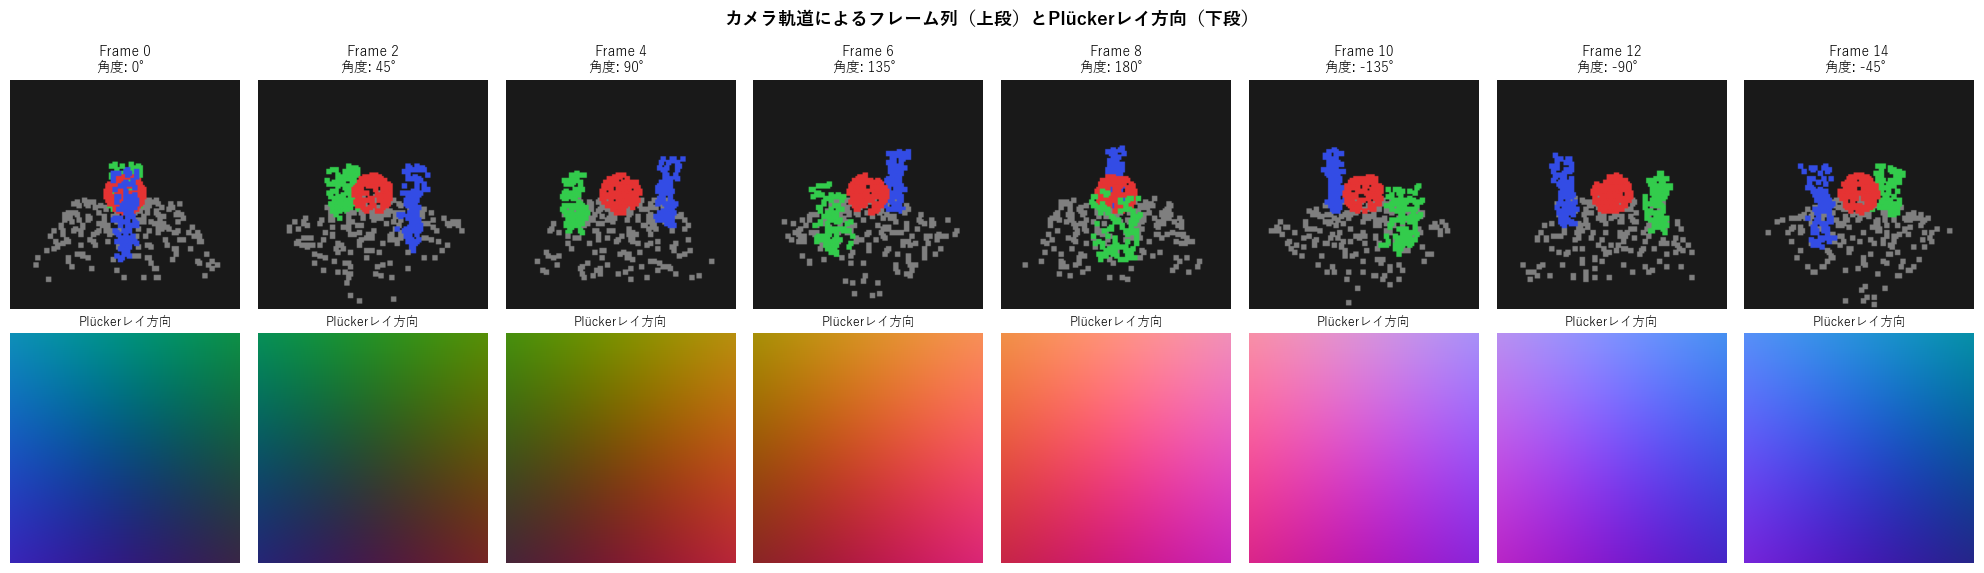

In [10]:
# ============================================================
# カメラ軌道フレーム列の可視化
# ============================================================

def show_camera_motion_frames(frames, cam_positions, frames_to_show=8):
    """カメラ軌道のフレーム列を表示する"""
    num_frames = frames.shape[0]
    step = max(1, num_frames // frames_to_show)
    
    fig, axes = plt.subplots(2, frames_to_show, figsize=(20, 6))
    
    for j in range(frames_to_show):
        f_idx = j * step
        if f_idx >= num_frames:
            f_idx = num_frames - 1
        
        # フレーム画像
        axes[0, j].imshow(np.clip(frames[f_idx], 0, 1))
        angle = np.degrees(np.arctan2(cam_positions[f_idx, 2], cam_positions[f_idx, 0]))
        axes[0, j].set_title(f'Frame {f_idx}\n角度: {angle:.0f}°', fontsize=10)
        axes[0, j].axis('off')
        
        # Plücker rayのDirection成分
        plucker = compute_plucker_rays(
            cam_positions[f_idx],
            np.array([0, 0, 0]),
            (frames.shape[1], frames.shape[2]),
            fov=60.0
        )
        # Direction (d_x, d_y, d_z) をRGBとして表示
        d_rgb = (plucker[:, :, 3:] + 1) / 2  # [-1,1] → [0,1]
        axes[1, j].imshow(np.clip(d_rgb, 0, 1))
        axes[1, j].set_title('Plückerレイ方向', fontsize=9)
        axes[1, j].axis('off')
    
    axes[0, 0].set_ylabel('レンダリング', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('レイ方向', fontsize=11, fontweight='bold')
    
    plt.suptitle('カメラ軌道によるフレーム列（上段）とPlückerレイ方向（下段）',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_camera_motion_frames(frames, cam_positions)

<a id="section6"></a>
## 6. オプティカルフロー概念と可視化

### 📊 オプティカルフローとは

オプティカルフロー（光学的流れ）は、連続するフレーム間の **各ピクセルの見かけ上の動き** をベクトル場として表現したものです。

$$
\text{フロー}: \mathbf{F}(u, v) = (\Delta u, \Delta v)
$$

各ピクセル $(u, v)$ に対して、次フレームでの移動先 $(u + \Delta u, v + \Delta v)$ を示します。

### カメラ運動 vs 物体運動のフロー特性

| 運動タイプ | フローの特徴 | パターン |
|-----------|-------------|---------|
| カメラ並進 | 全体的に均一なフロー | → → → |
| カメラ回転 | 放射状・渦巻き状のフロー | ↗ → ↘ |
| カメラ前進 | 画像中心から放射状に拡大 | ← ↑ ↗ → ↘ ↓ ← |
| 物体運動 | 物体領域のみ局所的なフロー | ○→ (周囲は静止) |

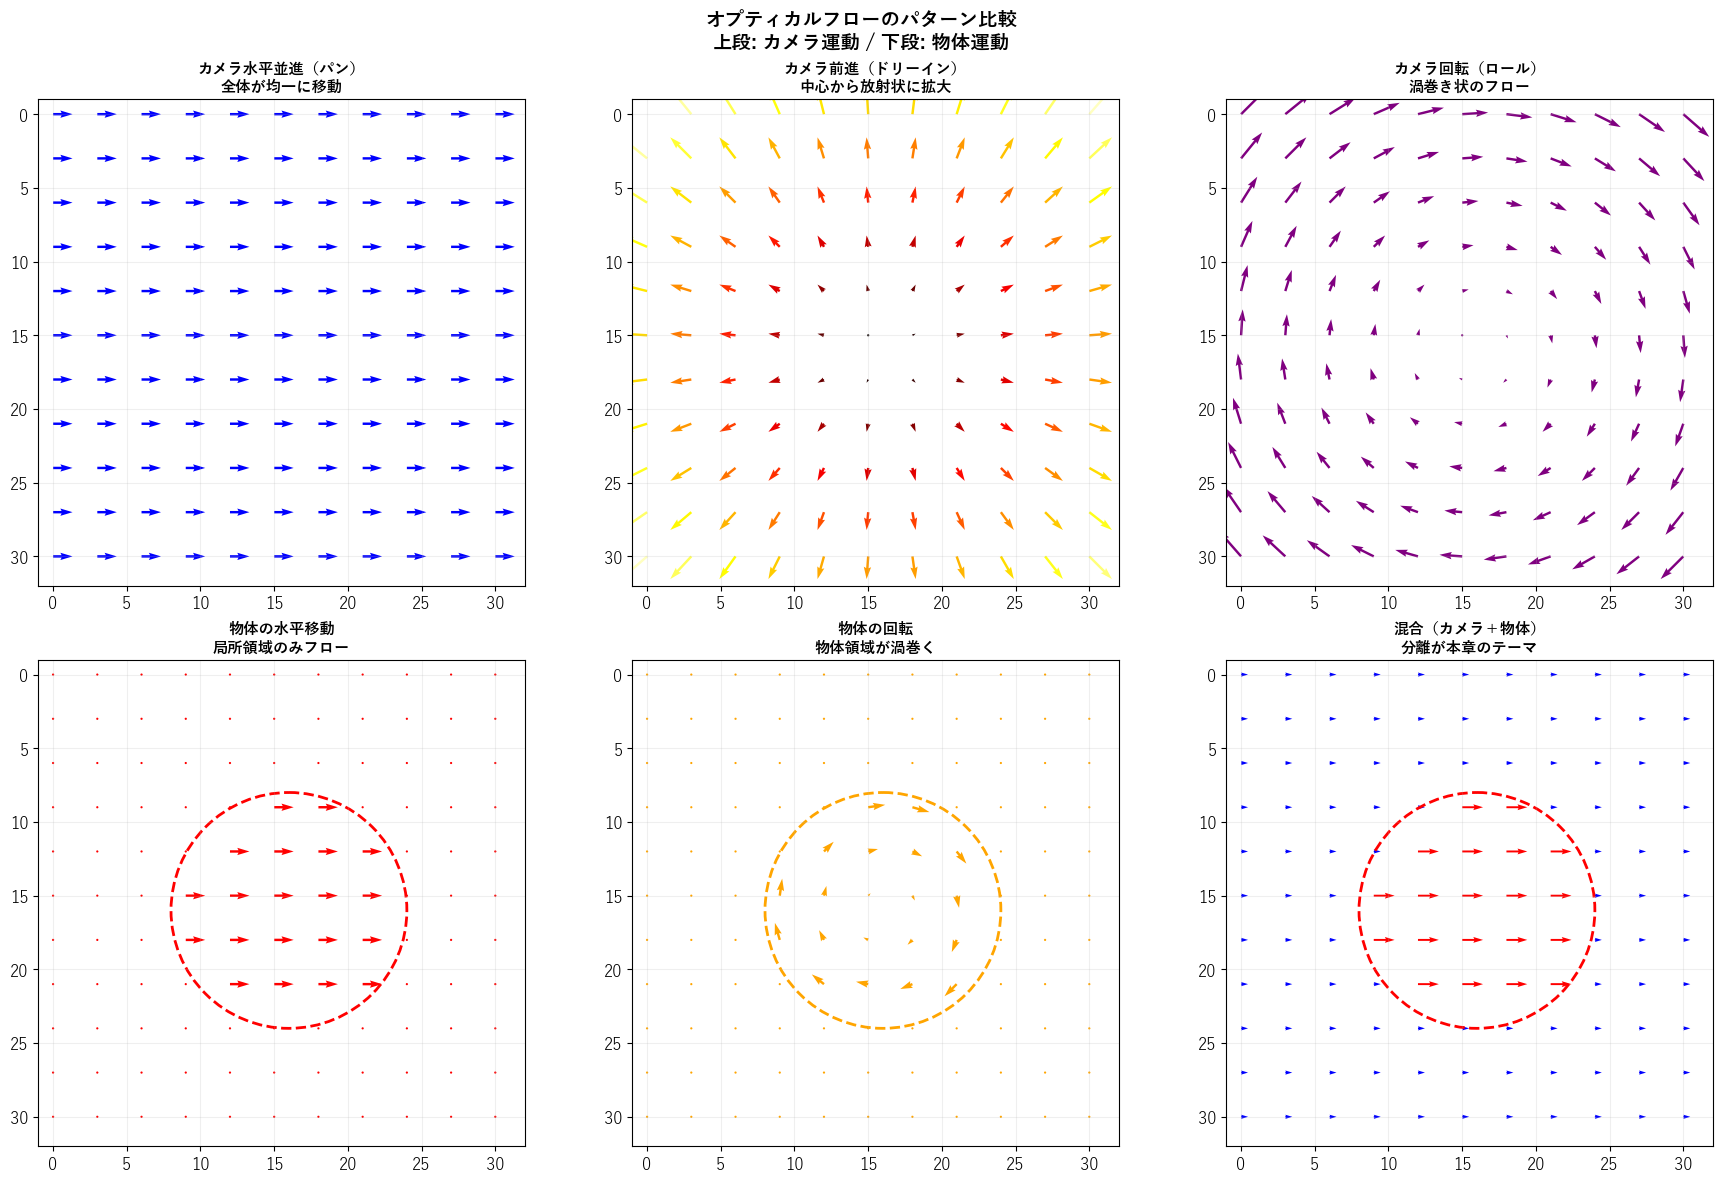

In [11]:
# ============================================================
# オプティカルフローのパターン可視化
# ============================================================

def visualize_flow_patterns():
    """カメラ運動と物体運動に対応するフローパターンを可視化"""
    H, W = 32, 32
    y, x = np.mgrid[0:H, 0:W]
    cx, cy = W / 2, H / 2
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # --- カメラ運動パターン ---
    # 1. カメラ水平並進（パン）
    flow_u = np.ones((H, W)) * 2.0
    flow_v = np.zeros((H, W))
    ax = axes[0, 0]
    ax.quiver(x[::3, ::3], y[::3, ::3], flow_u[::3, ::3], -flow_v[::3, ::3],
             color='blue', scale=50, width=0.005)
    ax.set_title('カメラ水平並進（パン）\n全体が均一に移動', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    # 2. カメラ前進（ドリーイン）
    flow_u = (x - cx) * 0.1
    flow_v = (y - cy) * 0.1
    ax = axes[0, 1]
    magnitude = np.sqrt(flow_u**2 + flow_v**2)
    ax.quiver(x[::3, ::3], y[::3, ::3], flow_u[::3, ::3], -flow_v[::3, ::3],
             magnitude[::3, ::3], cmap='hot', scale=30, width=0.005)
    ax.set_title('カメラ前進（ドリーイン）\n中心から放射状に拡大', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    # 3. カメラ回転（ロール）
    flow_u = -(y - cy) * 0.1
    flow_v = (x - cx) * 0.1
    ax = axes[0, 2]
    ax.quiver(x[::3, ::3], y[::3, ::3], flow_u[::3, ::3], -flow_v[::3, ::3],
             color='purple', scale=30, width=0.005)
    ax.set_title('カメラ回転（ロール）\n渦巻き状のフロー', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    # --- 物体運動パターン ---
    # 4. 物体の水平移動
    flow_u = np.zeros((H, W))
    flow_v = np.zeros((H, W))
    # 中央の物体領域だけフロー
    mask = ((x - cx)**2 + (y - cy)**2) < 8**2
    flow_u[mask] = 2.0
    ax = axes[1, 0]
    ax.quiver(x[::3, ::3], y[::3, ::3], flow_u[::3, ::3], -flow_v[::3, ::3],
             color='red', scale=50, width=0.005)
    # 物体領域を円で表示
    circle = plt.Circle((cx, cy), 8, fill=False, color='red', linewidth=2, linestyle='--')
    ax.add_patch(circle)
    ax.set_title('物体の水平移動\n局所領域のみフロー', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    # 5. 物体の回転
    flow_u = np.zeros((H, W))
    flow_v = np.zeros((H, W))
    flow_u[mask] = -(y[mask] - cy) * 0.15
    flow_v[mask] = (x[mask] - cx) * 0.15
    ax = axes[1, 1]
    ax.quiver(x[::3, ::3], y[::3, ::3], flow_u[::3, ::3], -flow_v[::3, ::3],
             color='orange', scale=30, width=0.005)
    circle = plt.Circle((cx, cy), 8, fill=False, color='orange', linewidth=2, linestyle='--')
    ax.add_patch(circle)
    ax.set_title('物体の回転\n物体領域が渦巻く', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    # 6. 混合（カメラ並進 + 物体移動）
    flow_u = np.ones((H, W)) * 1.0  # カメラ並進
    flow_v = np.zeros((H, W))
    flow_u[mask] += 2.0  # 物体移動を追加
    ax = axes[1, 2]
    colors_arr = np.where(mask[::3, ::3], 'red', 'blue')
    for i_q in range(0, H, 3):
        for j_q in range(0, W, 3):
            c = 'red' if mask[i_q, j_q] else 'blue'
            ax.quiver(x[i_q, j_q], y[i_q, j_q],
                     flow_u[i_q, j_q], -flow_v[i_q, j_q],
                     color=c, scale=70, width=0.004)
    circle = plt.Circle((cx, cy), 8, fill=False, color='red', linewidth=2, linestyle='--')
    ax.add_patch(circle)
    ax.set_title('混合（カメラ＋物体）\n分離が本章のテーマ', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, W)
    ax.set_ylim(H, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    plt.suptitle('オプティカルフローのパターン比較\n上段: カメラ運動 / 下段: 物体運動',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_flow_patterns()

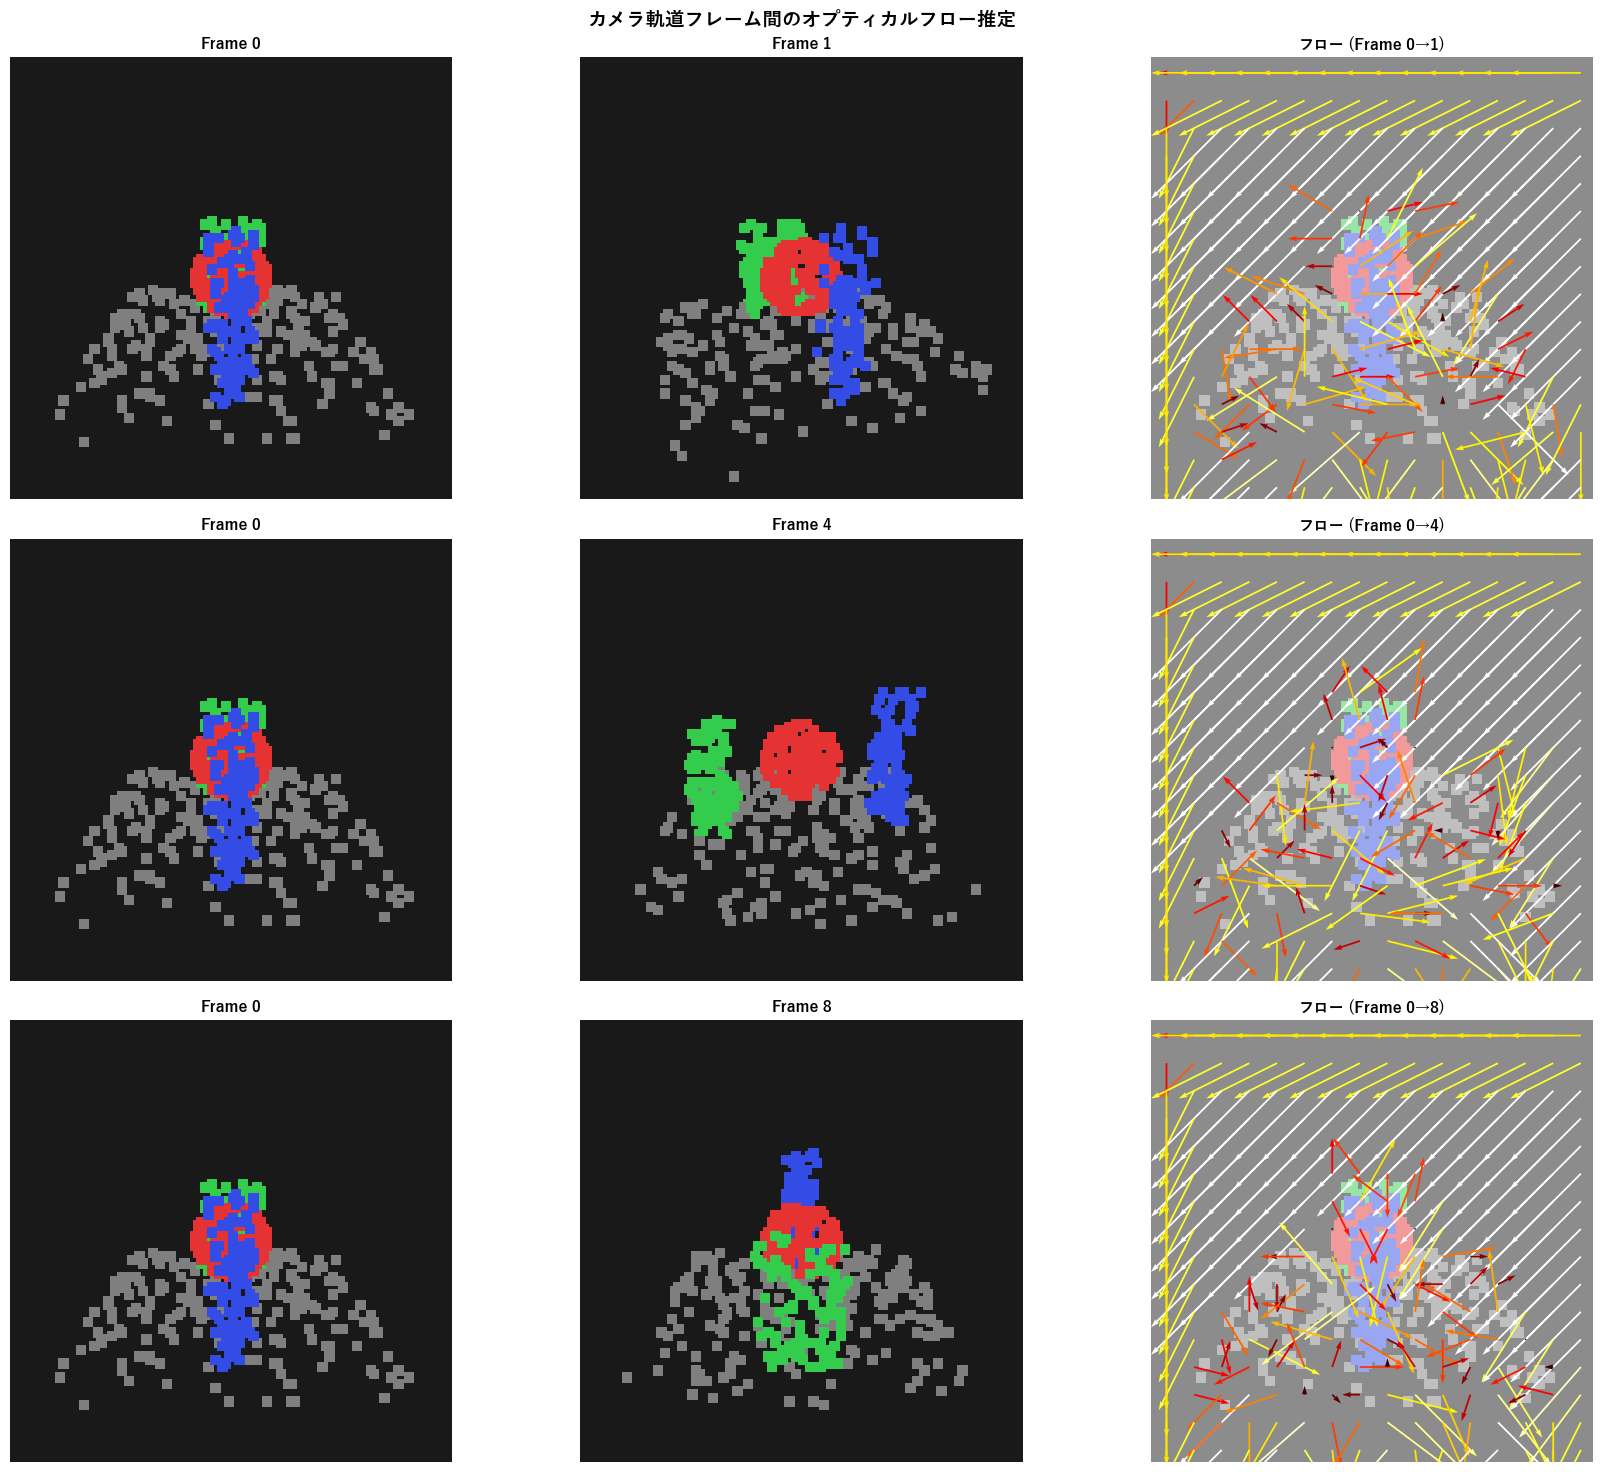

カメラが周回するため、フレーム間隔が大きいほどフローも大きくなります。
全体的に一方向に動くパターン = カメラ運動の特徴です。


In [12]:
# ============================================================
# カメラ軌道フレームからのオプティカルフロー推定（簡易版）
# ============================================================

def estimate_simple_flow(frame1, frame2, block_size=8, search_range=12):
    """簡易ブロックマッチングによるオプティカルフロー推定
    
    教育目的のシンプルな実装。
    各ブロックについて、最も類似するブロックを探索する。
    
    Args:
        frame1: (H, W) グレースケール画像（参照フレーム）
        frame2: (H, W) グレースケール画像（対象フレーム）
        block_size: ブロックサイズ
        search_range: 探索範囲（ピクセル）
    
    Returns:
        flow_u: (H//block_size, W//block_size) 水平フロー
        flow_v: (H//block_size, W//block_size) 垂直フロー
    """
    H, W = frame1.shape
    bh = H // block_size
    bw = W // block_size
    
    flow_u = np.zeros((bh, bw))
    flow_v = np.zeros((bh, bw))
    
    for bi in range(bh):
        for bj in range(bw):
            # 参照ブロック
            y0 = bi * block_size
            x0 = bj * block_size
            ref_block = frame1[y0:y0+block_size, x0:x0+block_size]
            
            best_sad = float('inf')
            best_du, best_dv = 0, 0
            
            # 探索
            for dv in range(-search_range, search_range + 1, 2):
                for du in range(-search_range, search_range + 1, 2):
                    ty = y0 + dv
                    tx = x0 + du
                    
                    if ty < 0 or ty + block_size > H or tx < 0 or tx + block_size > W:
                        continue
                    
                    cand_block = frame2[ty:ty+block_size, tx:tx+block_size]
                    sad = np.sum(np.abs(ref_block - cand_block))
                    
                    if sad < best_sad:
                        best_sad = sad
                        best_du = du
                        best_dv = dv
            
            flow_u[bi, bj] = best_du
            flow_v[bi, bj] = best_dv
    
    return flow_u, flow_v


# --- カメラ軌道フレームからフローを推定 ---
# グレースケール変換
gray_frames = np.mean(frames, axis=-1)  # (N, H, W)

# 連続する2フレーム間のフロー
frame_pairs = [(0, 1), (0, 4), (0, 8)]

fig, axes = plt.subplots(len(frame_pairs), 3, figsize=(18, 5 * len(frame_pairs)))

for row, (f1_idx, f2_idx) in enumerate(frame_pairs):
    f1 = gray_frames[f1_idx]
    f2 = gray_frames[f2_idx]
    
    flow_u, flow_v = estimate_simple_flow(f1, f2, block_size=8, search_range=16)
    
    bh, bw = flow_u.shape
    by, bx = np.mgrid[0:bh, 0:bw]
    
    # フレーム1
    axes[row, 0].imshow(np.clip(frames[f1_idx], 0, 1))
    axes[row, 0].set_title(f'Frame {f1_idx}', fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')
    
    # フレーム2
    axes[row, 1].imshow(np.clip(frames[f2_idx], 0, 1))
    axes[row, 1].set_title(f'Frame {f2_idx}', fontsize=11, fontweight='bold')
    axes[row, 1].axis('off')
    
    # フロー（quiverプロット）
    mag = np.sqrt(flow_u**2 + flow_v**2)
    axes[row, 2].imshow(np.clip(frames[f1_idx], 0, 1), alpha=0.5)
    q = axes[row, 2].quiver(
        bx * 8 + 4, by * 8 + 4,
        flow_u, flow_v,
        mag, cmap='hot', scale=100, width=0.004
    )
    axes[row, 2].set_title(f'フロー (Frame {f1_idx}→{f2_idx})', fontsize=11, fontweight='bold')
    axes[row, 2].axis('off')

plt.suptitle('カメラ軌道フレーム間のオプティカルフロー推定',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("カメラが周回するため、フレーム間隔が大きいほどフローも大きくなります。")
print("全体的に一方向に動くパターン = カメラ運動の特徴です。")

<a id="section7"></a>
## 7. 回転キューブのフレーム列合成

### 📊 3Dワイヤーフレームの投影

ここでは、3D空間で回転するキューブをピンホールカメラに投影し、
2Dフレーム列を合成します。

これは **物体運動** の代表的な例です。カメラは固定で、物体（キューブ）が回転します。

**処理の流れ**:
1. キューブの8頂点を定義
2. 各フレームで回転行列を適用
3. ピンホール投影で2D座標に変換
4. 辺を描画してフレームを生成

In [13]:
# ============================================================
# 回転キューブのフレーム列合成
# ============================================================

def create_cube_vertices():
    """単位キューブの8頂点を生成（中心が原点）
    
    Returns:
        vertices: (8, 3) キューブの頂点座標
        edges: list of (i, j) 辺のインデックスペア
        faces: list of (i, j, k, l) 面のインデックス
    """
    # 8頂点
    vertices = np.array([
        [-1, -1, -1],
        [ 1, -1, -1],
        [ 1,  1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
        [ 1, -1,  1],
        [ 1,  1,  1],
        [-1,  1,  1],
    ], dtype=np.float64) * 0.8  # スケール
    
    # 12辺
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),  # 前面
        (4, 5), (5, 6), (6, 7), (7, 4),  # 背面
        (0, 4), (1, 5), (2, 6), (3, 7),  # 接続
    ]
    
    # 6面（各面4頂点、描画用）
    faces = [
        (0, 1, 2, 3),  # 前
        (4, 5, 6, 7),  # 後
        (0, 1, 5, 4),  # 下
        (2, 3, 7, 6),  # 上
        (0, 3, 7, 4),  # 左
        (1, 2, 6, 5),  # 右
    ]
    
    return vertices, edges, faces


def render_wireframe_cube(vertices_2d, edges, visible_verts,
                          image_size=(128, 128), face_colors=None):
    """ワイヤーフレームキューブを画像にレンダリング
    
    Args:
        vertices_2d: (8, 2) 投影された2D座標
        edges: 辺のリスト
        visible_verts: (8,) 各頂点の可視フラグ
        image_size: (H, W)
        face_colors: 辺の色リスト
    
    Returns:
        frame: (H, W, 3) RGB画像
    """
    H, W = image_size
    frame = np.ones((H, W, 3)) * 0.05  # 暗い背景
    
    # 辺の色（面ごとに色を割り当て）
    edge_colors = [
        [1.0, 0.3, 0.3],  # 赤系
        [0.3, 1.0, 0.3],  # 緑系
        [0.3, 0.3, 1.0],  # 青系
        [1.0, 1.0, 0.3],  # 黄系
        [1.0, 0.3, 1.0],  # マゼンタ系
        [0.3, 1.0, 1.0],  # シアン系
        [1.0, 0.6, 0.3],
        [0.6, 0.3, 1.0],
        [0.8, 0.8, 0.8],
        [0.8, 0.8, 0.8],
        [0.8, 0.8, 0.8],
        [0.8, 0.8, 0.8],
    ]
    
    for e_idx, (i, j) in enumerate(edges):
        if not (visible_verts[i] and visible_verts[j]):
            continue
        
        # Bresenhamの直線描画（簡易版）
        u0, v0 = int(round(vertices_2d[i, 0])), int(round(vertices_2d[i, 1]))
        u1, v1 = int(round(vertices_2d[j, 0])), int(round(vertices_2d[j, 1]))
        
        # 直線上の点を列挙
        num_steps = max(abs(u1 - u0), abs(v1 - v0), 1)
        for s in range(num_steps + 1):
            t = s / num_steps
            u = int(round(u0 + t * (u1 - u0)))
            v = int(round(v0 + t * (v1 - v0)))
            
            # 太さ2の線
            for du in range(-1, 2):
                for dv in range(-1, 2):
                    vu = v + dv
                    uu = u + du
                    if 0 <= vu < H and 0 <= uu < W:
                        color = edge_colors[e_idx % len(edge_colors)]
                        frame[vu, uu] = color
    
    # 頂点にマーカー
    for i in range(len(vertices_2d)):
        if visible_verts[i]:
            u, v = int(round(vertices_2d[i, 0])), int(round(vertices_2d[i, 1]))
            for du in range(-2, 3):
                for dv in range(-2, 3):
                    vu = v + dv
                    uu = u + du
                    if 0 <= vu < H and 0 <= uu < W:
                        frame[vu, uu] = [1.0, 1.0, 1.0]
    
    return frame


def generate_rotating_cube_frames(num_frames=24, image_size=(128, 128),
                                    camera_pos=np.array([0, 2, 6]),
                                    look_at=np.array([0, 0, 0]),
                                    fov=60.0):
    """回転キューブのフレーム列を合成する
    
    Args:
        num_frames: フレーム数
        image_size: (H, W) 画像サイズ
        camera_pos: (3,) カメラ位置（固定）
        look_at: (3,) 注視点
        fov: 画角
    
    Returns:
        frames: (num_frames, H, W, 3) RGBフレーム列
        rotated_vertices_list: 各フレームの3D頂点座標
    """
    vertices, edges, faces = create_cube_vertices()
    
    frames = np.zeros((num_frames, *image_size, 3))
    rotated_vertices_list = []
    
    for f_idx in range(num_frames):
        # フレームごとの回転角度
        angle_y = 2 * np.pi * f_idx / num_frames  # Y軸周りに1回転
        angle_x = 0.3 * np.sin(2 * np.pi * f_idx / num_frames)  # X軸は揺れる
        
        # 回転行列を合成
        R = rotation_matrix_y(angle_y) @ rotation_matrix_x(angle_x)
        
        # 頂点を回転
        rotated_verts = (R @ vertices.T).T  # (8, 3)
        rotated_vertices_list.append(rotated_verts)
        
        # カメラ投影
        uv, depth, visible = project_points(
            rotated_verts, camera_pos, look_at, image_size, fov
        )
        
        # ワイヤーフレーム描画
        frame = render_wireframe_cube(uv, edges, visible, image_size)
        frames[f_idx] = frame
    
    return frames, rotated_vertices_list

# --- 実行 ---
print("回転キューブのフレームを生成中...")
cube_frames, cube_verts_list = generate_rotating_cube_frames(
    num_frames=24, image_size=(128, 128)
)
print(f"フレーム数: {cube_frames.shape[0]}")
print(f"✅ 回転キューブのフレーム列合成完了")

回転キューブのフレームを生成中...
フレーム数: 24
✅ 回転キューブのフレーム列合成完了


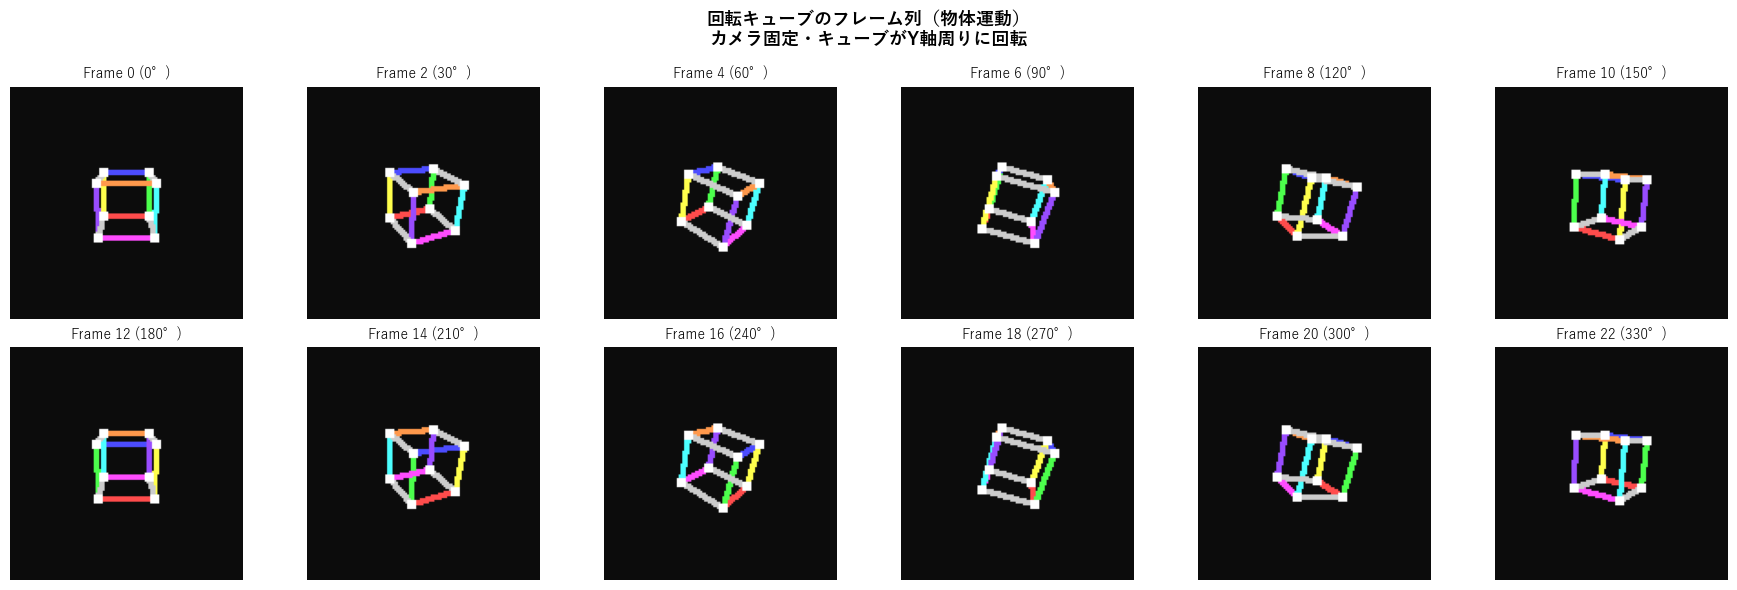

In [14]:
# ============================================================
# 回転キューブのフレーム列を表示
# ============================================================

def show_rotating_cube_frames(frames, num_show=12):
    """回転キューブのフレーム列を表示"""
    num_frames = frames.shape[0]
    step = max(1, num_frames // num_show)
    actual_show = min(num_show, num_frames)
    
    cols = min(actual_show, 6)
    rows = (actual_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    if rows == 1:
        axes = axes[np.newaxis, :]
    
    for idx in range(actual_show):
        f_idx = idx * step
        if f_idx >= num_frames:
            f_idx = num_frames - 1
        row, col = idx // cols, idx % cols
        axes[row, col].imshow(np.clip(frames[f_idx], 0, 1))
        angle = 360.0 * f_idx / num_frames
        axes[row, col].set_title(f'Frame {f_idx} ({angle:.0f}°)', fontsize=10)
        axes[row, col].axis('off')
    
    # 余ったサブプロットを非表示
    for idx in range(actual_show, rows * cols):
        row, col = idx // cols, idx % cols
        axes[row, col].axis('off')
    
    plt.suptitle('回転キューブのフレーム列（物体運動）\nカメラ固定・キューブがY軸周りに回転',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_rotating_cube_frames(cube_frames, num_show=12)

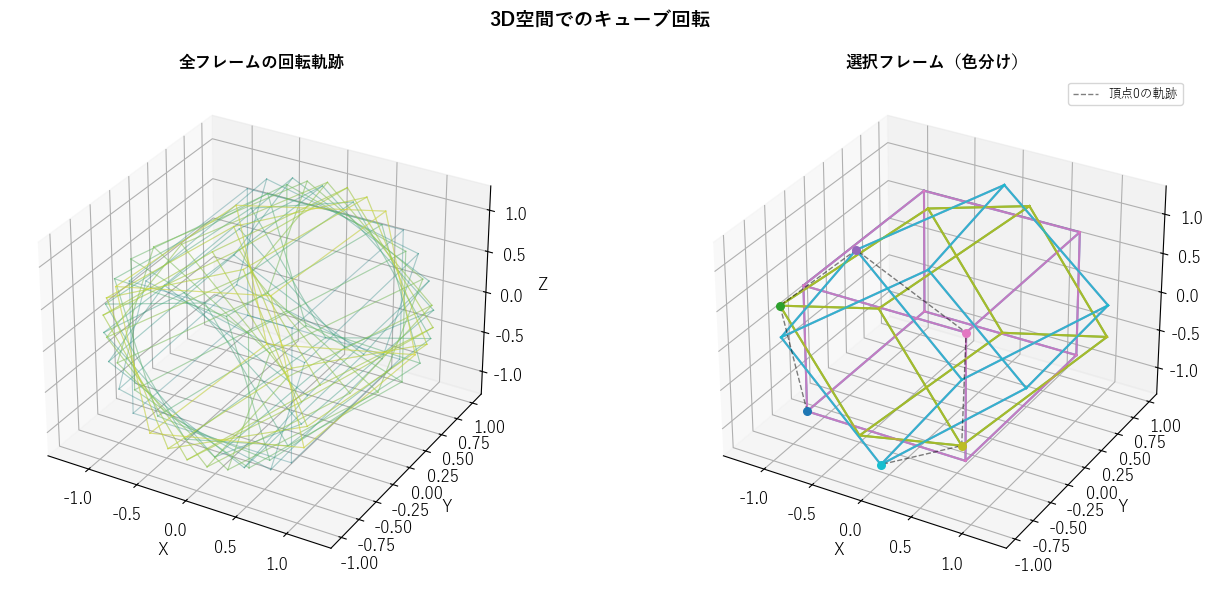

In [15]:
# ============================================================
# キューブの回転軌跡を3Dで可視化
# ============================================================

def visualize_cube_rotation_3d(verts_list, num_show=6):
    """キューブの回転軌跡を3Dで表示"""
    fig = plt.figure(figsize=(14, 6))
    
    _, edges, _ = create_cube_vertices()
    
    # --- 左: 全フレームの重ね合わせ ---
    ax1 = fig.add_subplot(121, projection='3d')
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(verts_list)))
    
    for f_idx, verts in enumerate(verts_list):
        alpha = 0.15 + 0.85 * (f_idx / len(verts_list))
        for i, j in edges:
            ax1.plot([verts[i, 0], verts[j, 0]],
                    [verts[i, 1], verts[j, 1]],
                    [verts[i, 2], verts[j, 2]],
                    color=colors[f_idx], alpha=alpha * 0.5, linewidth=0.8)
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('全フレームの回転軌跡', fontsize=12, fontweight='bold')
    
    # --- 右: 選択フレームの詳細 ---
    ax2 = fig.add_subplot(122, projection='3d')
    
    step = max(1, len(verts_list) // num_show)
    show_colors = plt.cm.tab10(np.linspace(0, 1, num_show))
    
    for s_idx in range(num_show):
        f_idx = s_idx * step
        if f_idx >= len(verts_list):
            break
        verts = verts_list[f_idx]
        for i, j in edges:
            ax2.plot([verts[i, 0], verts[j, 0]],
                    [verts[i, 1], verts[j, 1]],
                    [verts[i, 2], verts[j, 2]],
                    color=show_colors[s_idx], linewidth=1.5, alpha=0.8)
        # 頂点0の軌跡をマーク
        ax2.scatter(*verts[0], color=show_colors[s_idx], s=30, zorder=5)
    
    # 頂点0の軌跡を線で結ぶ
    traj = np.array([verts_list[s * step][0] for s in range(num_show) if s * step < len(verts_list)])
    ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'k--', linewidth=1, alpha=0.5, label='頂点0の軌跡')
    
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('選択フレーム（色分け）', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    
    plt.suptitle('3D空間でのキューブ回転', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_cube_rotation_3d(cube_verts_list)

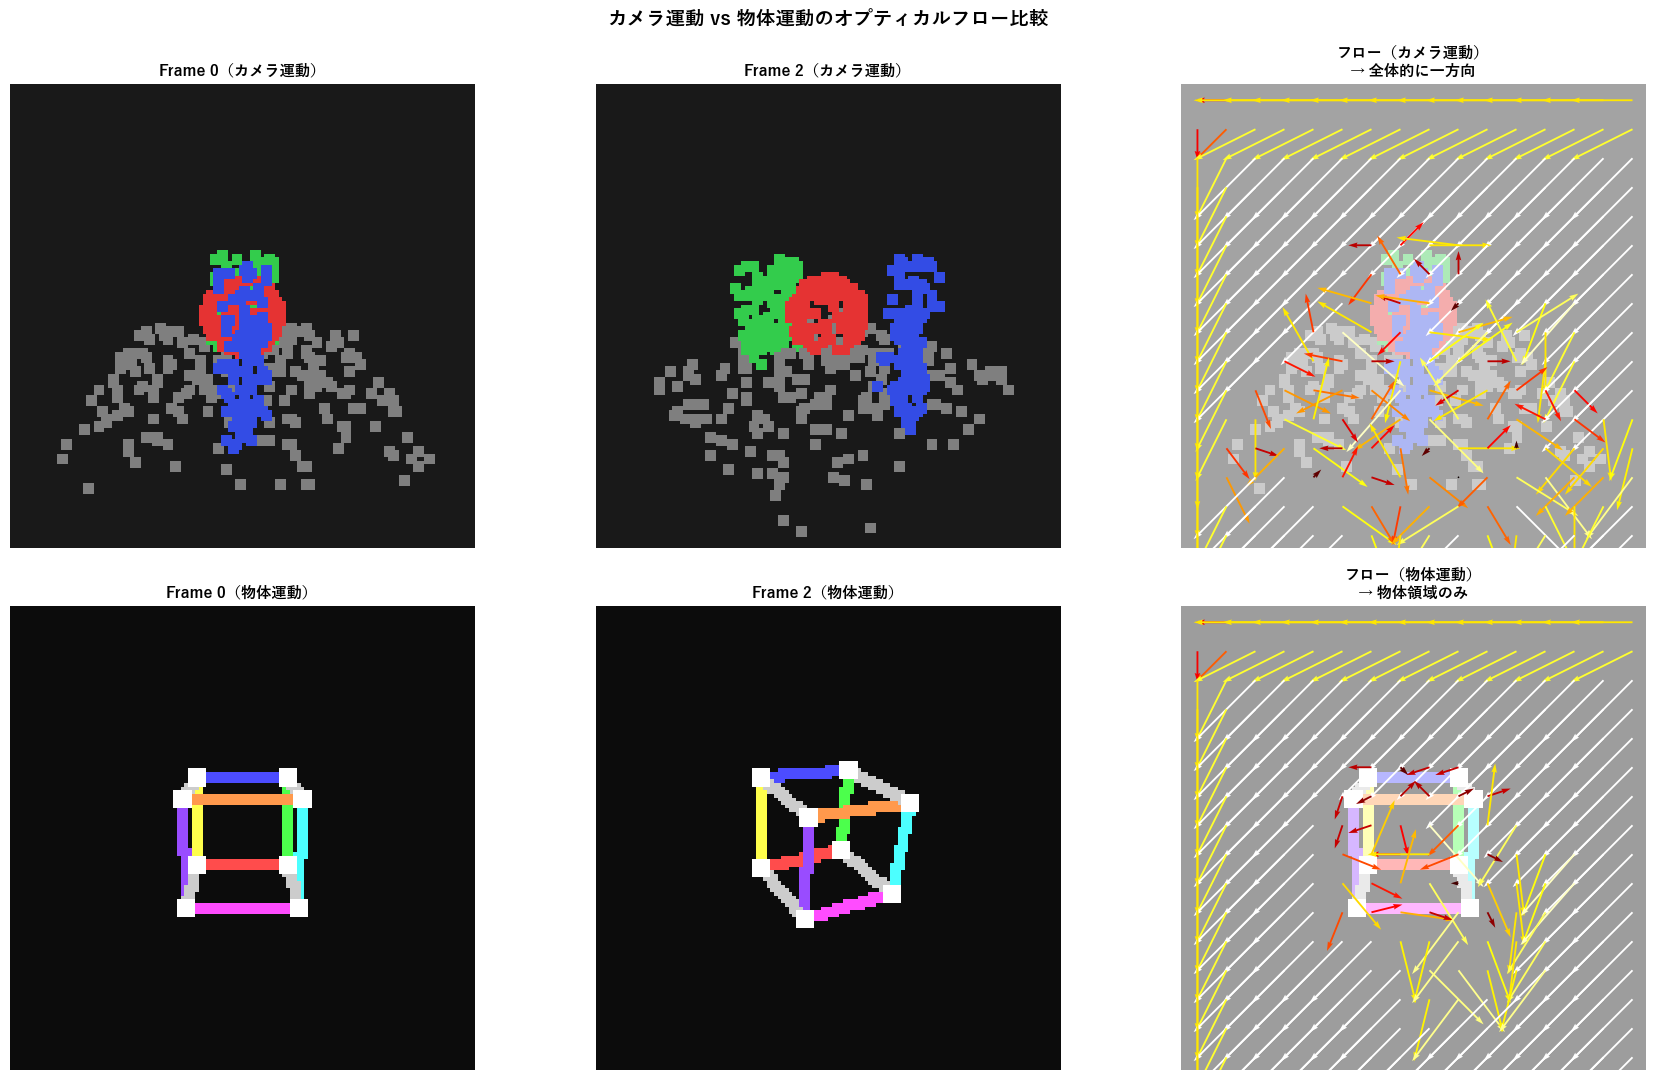

フロー統計の比較
カメラ運動フロー — 平均magnitude: 17.38, 最大: 22.63
物体運動フロー — 平均magnitude: 19.02, 最大: 22.63

カメラ運動: 全体的に大きなフロー（シーン全体が動く）
物体運動: 局所的なフロー（物体領域のみ大きなフロー）


In [16]:
# ============================================================
# カメラ運動 vs 物体運動のフロー比較
# ============================================================

def compare_camera_vs_object_flow():
    """カメラ運動と物体運動のオプティカルフロー差異を可視化"""
    
    # --- カメラ運動フレーム（軌道カメラ）---
    cam_gray = np.mean(frames, axis=-1)  # generate_camera_motion_framesの結果
    flow_cam_u, flow_cam_v = estimate_simple_flow(
        cam_gray[0], cam_gray[2], block_size=8, search_range=16
    )
    
    # --- 物体運動フレーム（回転キューブ）---
    cube_gray = np.mean(cube_frames, axis=-1)
    flow_obj_u, flow_obj_v = estimate_simple_flow(
        cube_gray[0], cube_gray[2], block_size=8, search_range=16
    )
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    bh_c, bw_c = flow_cam_u.shape
    by_c, bx_c = np.mgrid[0:bh_c, 0:bw_c]
    
    bh_o, bw_o = flow_obj_u.shape
    by_o, bx_o = np.mgrid[0:bh_o, 0:bw_o]
    
    # カメラ運動
    axes[0, 0].imshow(np.clip(frames[0], 0, 1))
    axes[0, 0].set_title('Frame 0（カメラ運動）', fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(np.clip(frames[2], 0, 1))
    axes[0, 1].set_title('Frame 2（カメラ運動）', fontsize=11, fontweight='bold')
    axes[0, 1].axis('off')
    
    mag_cam = np.sqrt(flow_cam_u**2 + flow_cam_v**2)
    axes[0, 2].imshow(np.clip(frames[0], 0, 1), alpha=0.4)
    axes[0, 2].quiver(bx_c * 8 + 4, by_c * 8 + 4, flow_cam_u, flow_cam_v,
                      mag_cam, cmap='hot', scale=120, width=0.004)
    axes[0, 2].set_title('フロー（カメラ運動）\n→ 全体的に一方向', fontsize=11, fontweight='bold')
    axes[0, 2].axis('off')
    
    # 物体運動
    axes[1, 0].imshow(np.clip(cube_frames[0], 0, 1))
    axes[1, 0].set_title('Frame 0（物体運動）', fontsize=11, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(np.clip(cube_frames[2], 0, 1))
    axes[1, 1].set_title('Frame 2（物体運動）', fontsize=11, fontweight='bold')
    axes[1, 1].axis('off')
    
    mag_obj = np.sqrt(flow_obj_u**2 + flow_obj_v**2)
    axes[1, 2].imshow(np.clip(cube_frames[0], 0, 1), alpha=0.4)
    axes[1, 2].quiver(bx_o * 8 + 4, by_o * 8 + 4, flow_obj_u, flow_obj_v,
                      mag_obj, cmap='hot', scale=120, width=0.004)
    axes[1, 2].set_title('フロー（物体運動）\n→ 物体領域のみ', fontsize=11, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.suptitle('カメラ運動 vs 物体運動のオプティカルフロー比較',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("="*60)
    print("フロー統計の比較")
    print("="*60)
    print(f"カメラ運動フロー — 平均magnitude: {mag_cam.mean():.2f}, 最大: {mag_cam.max():.2f}")
    print(f"物体運動フロー — 平均magnitude: {mag_obj.mean():.2f}, 最大: {mag_obj.max():.2f}")
    print()
    print("カメラ運動: 全体的に大きなフロー（シーン全体が動く）")
    print("物体運動: 局所的なフロー（物体領域のみ大きなフロー）")

compare_camera_vs_object_flow()

<a id="section8"></a>
## 8. 動画生成AIでの応用 — MotionCtrl / CameraCtrl

### 📊 カメラ制御付き動画生成の最前線

近年の動画生成AIでは、カメラ運動と物体運動を明示的に分離・制御する手法が注目されています。

### MotionCtrl (2023)

**アーキテクチャの要点**:
- U-Netの各層にカメラ運動のエンコーディングを注入
- カメラ運動は **Camera Motion Control Module (CMCM)** で処理
- 物体運動は **Object Motion Control Module (OMCM)** で独立に制御
- 2つのモジュールは互いに干渉しない設計

### CameraCtrl (2024)

**Plücker座標の活用**:
- 各フレームのカメラ姿勢をPlücker ray座標に変換（本章のSection 4で実装）
- Plücker座標をU-Netの条件入力として使用
- これにより、「前に進む」「右に回る」などのカメラ動作を正確に制御

```
入力: テキストプロンプト + カメラ軌道（Plücker座標列）
  ↓
[Text Encoder]  → テキスト埋め込み
[Plücker Encoder] → カメラ条件
  ↓
[Video Diffusion U-Net]
  - cross-attention (テキスト条件)
  - camera conditioning (Plücker条件)
  ↓
出力: カメラ制御された動画
```

### 手法の比較

| 手法 | カメラ表現 | 物体制御 | 特徴 |
|------|-----------|---------|------|
| MotionCtrl | 回転・並進行列 | トラジェクトリ点 | 二重モジュール |
| CameraCtrl | Plücker ray座標 | テキストのみ | Plückerの精密制御 |
| Direct-a-Video | Plücker + depth | テキスト | 深度マップ併用 |

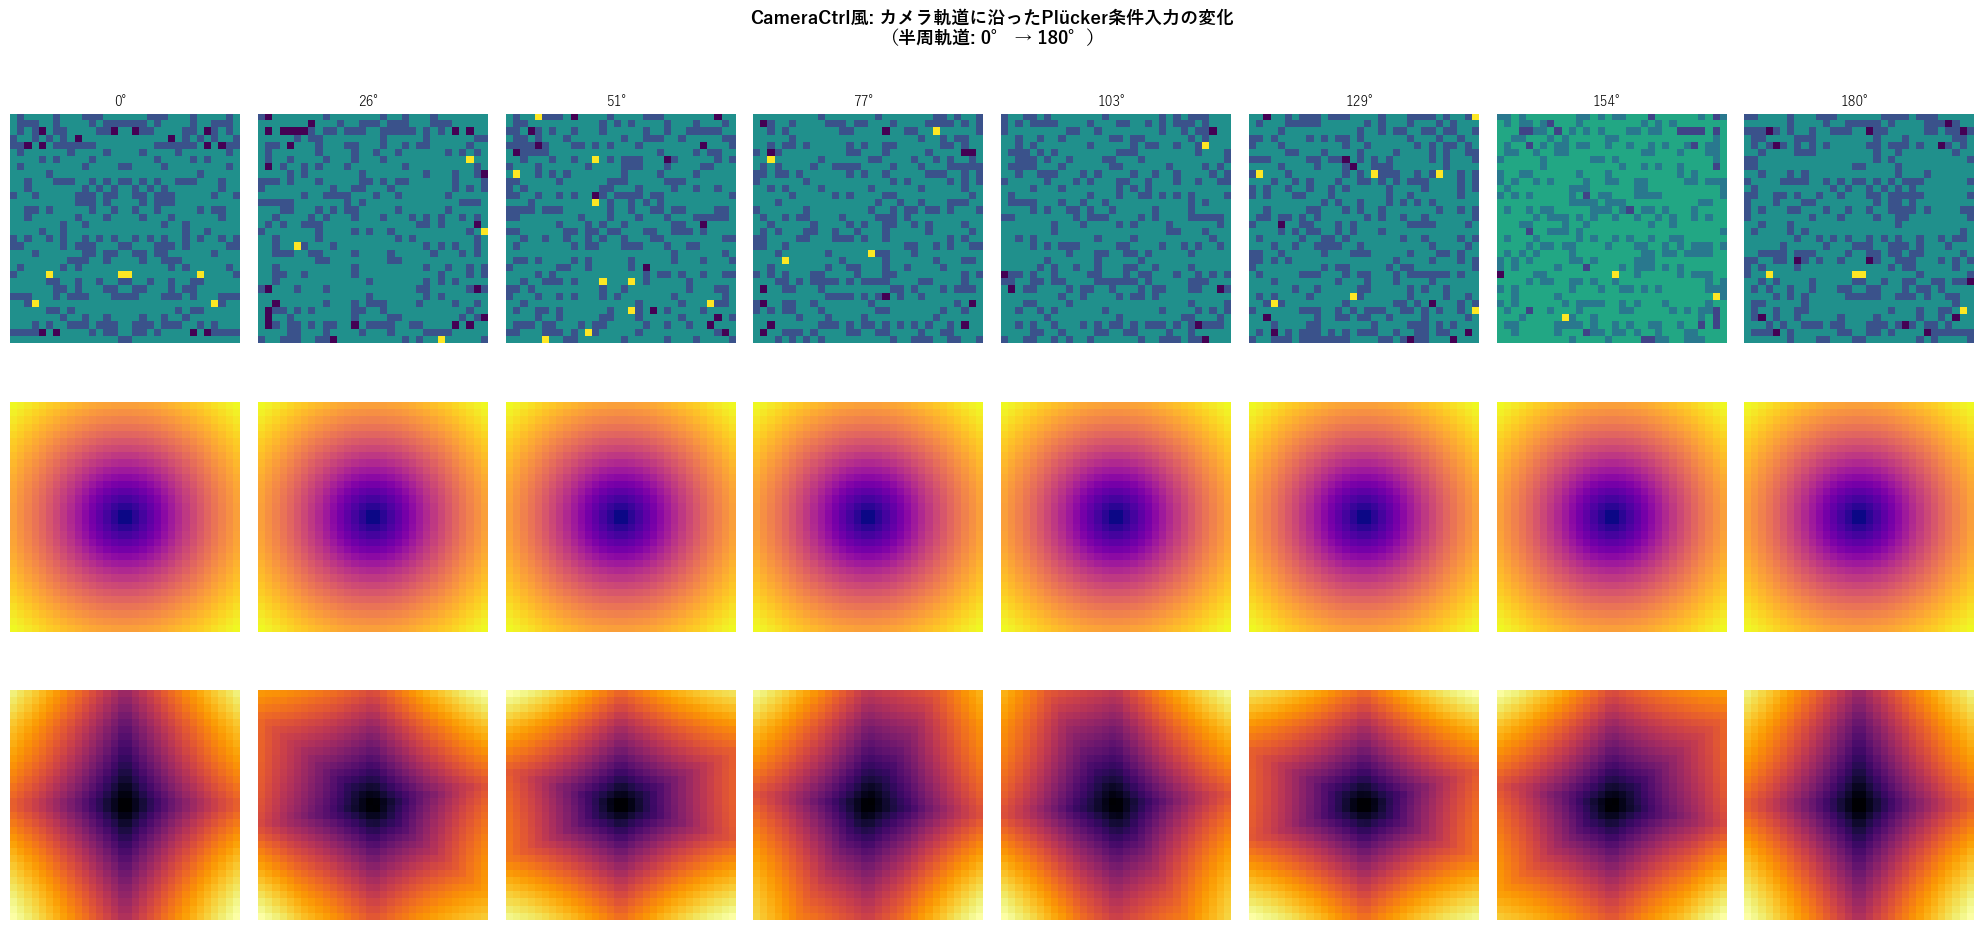

CameraCtrlでは、このPlücker座標をU-Netに条件付けとして注入します。
カメラが動くとPlückerパターンが滑らかに変化し、
ネットワークはこの変化から正しい視点変化を生成することを学習します。


In [17]:
# ============================================================
# CameraCtrl風のPlücker条件付け可視化
# ============================================================

def visualize_cameractrl_conditioning():
    """CameraCtrl風のカメラ条件付け処理のフローを可視化"""
    
    target = np.array([0, 0, 0])
    img_size = (32, 32)
    fov = 60.0
    
    # 軌道カメラのPlücker座標列
    num_frames = 8
    angles = np.linspace(0, np.pi, num_frames)  # 半周
    
    fig, axes = plt.subplots(3, num_frames, figsize=(20, 10))
    
    for f_idx, angle in enumerate(angles):
        cam_pos = np.array([5 * np.cos(angle), 2.0, 5 * np.sin(angle)])
        plucker = compute_plucker_rays(cam_pos, target, img_size, fov)
        
        # 行1: Direction のノルム（レイ方向パターン）
        d_norm = np.linalg.norm(plucker[:, :, 3:], axis=-1)
        axes[0, f_idx].imshow(d_norm, cmap='viridis')
        axes[0, f_idx].set_title(f'{np.degrees(angle):.0f}°', fontsize=10)
        axes[0, f_idx].axis('off')
        
        # 行2: Moment のノルム（位置情報）
        m_norm = np.linalg.norm(plucker[:, :, :3], axis=-1)
        axes[1, f_idx].imshow(m_norm, cmap='plasma')
        axes[1, f_idx].axis('off')
        
        # 行3: 6チャンネルの平均（全体的な条件入力の変化）
        mean_map = np.mean(np.abs(plucker), axis=-1)
        axes[2, f_idx].imshow(mean_map, cmap='inferno')
        axes[2, f_idx].axis('off')
    
    axes[0, 0].set_ylabel('Direction ||d||', fontsize=11, fontweight='bold',
                          rotation=0, labelpad=80, va='center')
    axes[1, 0].set_ylabel('Moment ||m||', fontsize=11, fontweight='bold',
                          rotation=0, labelpad=80, va='center')
    axes[2, 0].set_ylabel('全体平均 |p|', fontsize=11, fontweight='bold',
                          rotation=0, labelpad=80, va='center')
    
    plt.suptitle('CameraCtrl風: カメラ軌道に沿ったPlücker条件入力の変化\n'
                '（半周軌道: 0° → 180°）',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("CameraCtrlでは、このPlücker座標をU-Netに条件付けとして注入します。")
    print("カメラが動くとPlückerパターンが滑らかに変化し、")
    print("ネットワークはこの変化から正しい視点変化を生成することを学習します。")

visualize_cameractrl_conditioning()

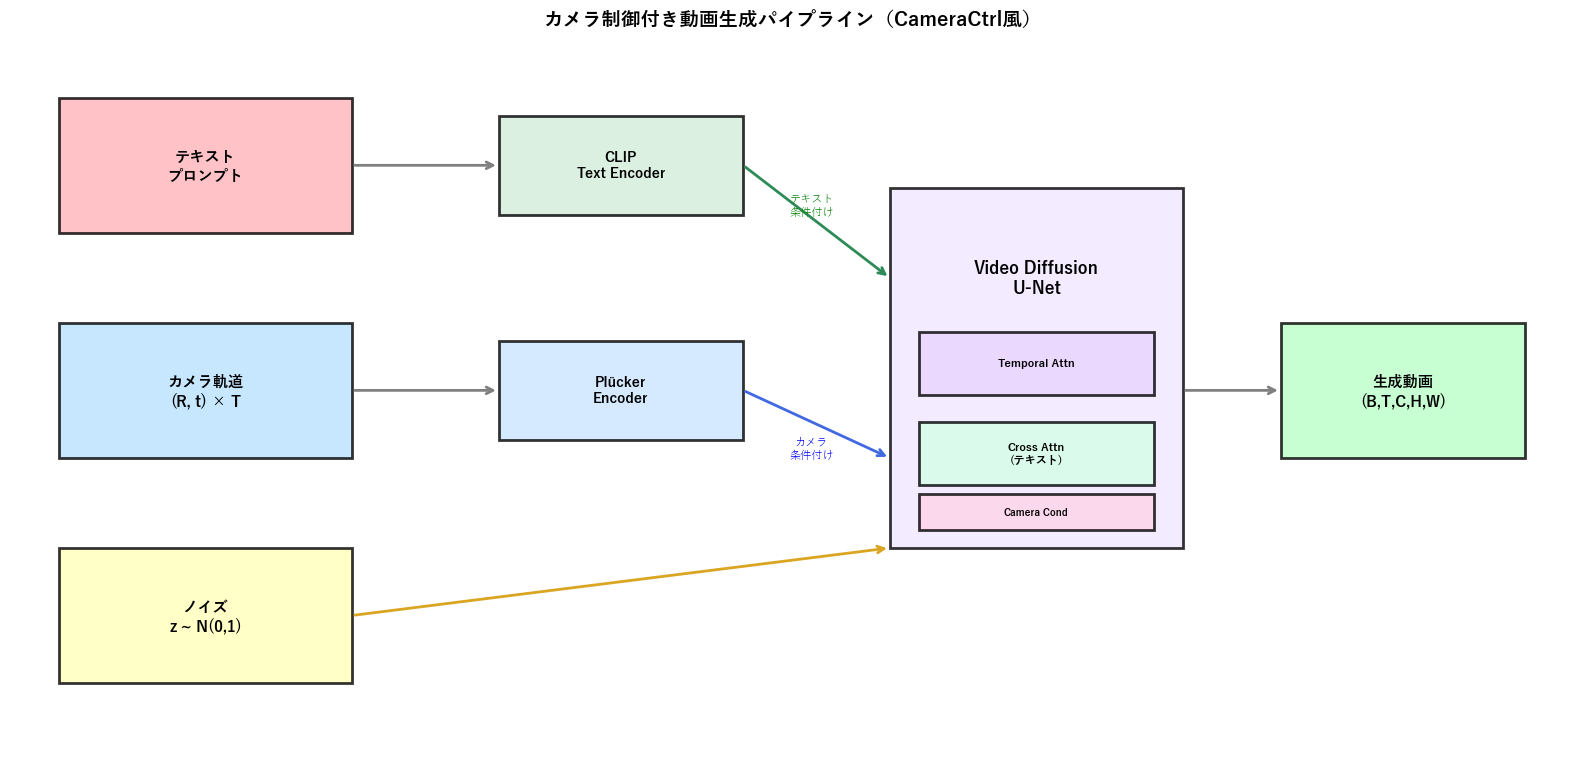

In [18]:
# ============================================================
# カメラ制御付き動画生成のパイプライン概念図
# ============================================================

def draw_pipeline_diagram():
    """MotionCtrl / CameraCtrl のパイプライン概念図"""
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis('off')
    
    # ブロック描画関数
    def draw_block(x, y, w, h, text, color, fontsize=10):
        rect = plt.Rectangle((x, y), w, h, facecolor=color,
                            edgecolor='black', linewidth=2, alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
               fontsize=fontsize, fontweight='bold', wrap=True)
    
    def draw_arrow(x1, y1, x2, y2, color='black'):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color=color, lw=2))
    
    # --- 入力 ---
    draw_block(0.5, 6, 3, 1.5, 'テキスト\nプロンプト', '#FFB3BA', 11)
    draw_block(0.5, 3.5, 3, 1.5, 'カメラ軌道\n(R, t) × T', '#BAE1FF', 11)
    draw_block(0.5, 1, 3, 1.5, 'ノイズ\nz ~ N(0,1)', '#FFFFBA', 11)
    
    # --- エンコーダ ---
    draw_block(5, 6.2, 2.5, 1.1, 'CLIP\nText Encoder', '#D4EDDA', 10)
    draw_block(5, 3.7, 2.5, 1.1, 'Plücker\nEncoder', '#CCE5FF', 10)
    
    # --- U-Net ---
    draw_block(9, 2.5, 3, 4, '', '#F0E6FF')
    ax.text(10.5, 5.5, 'Video Diffusion\nU-Net', ha='center', va='center',
           fontsize=12, fontweight='bold')
    
    # U-Net内部
    draw_block(9.3, 4.2, 2.4, 0.7, 'Temporal Attn', '#E8D4FF', 8)
    draw_block(9.3, 3.2, 2.4, 0.7, 'Cross Attn\n(テキスト)', '#D4FFE8', 8)
    draw_block(9.3, 2.7, 2.4, 0.4, 'Camera Cond', '#FFD4E8', 7)
    
    # --- 出力 ---
    draw_block(13, 3.5, 2.5, 1.5, '生成動画\n(B,T,C,H,W)', '#BAFFC9', 11)
    
    # --- 矢印 ---
    draw_arrow(3.5, 6.75, 5, 6.75, 'gray')
    draw_arrow(3.5, 4.25, 5, 4.25, 'gray')
    draw_arrow(7.5, 6.75, 9, 5.5, '#2E8B57')
    draw_arrow(7.5, 4.25, 9, 3.5, '#4169E1')
    draw_arrow(3.5, 1.75, 9, 2.5, '#DAA520')
    draw_arrow(12, 4.25, 13, 4.25, 'gray')
    
    # ラベル
    ax.text(8.2, 6.2, 'テキスト\n条件付け', fontsize=8, color='green', ha='center')
    ax.text(8.2, 3.5, 'カメラ\n条件付け', fontsize=8, color='blue', ha='center')
    
    ax.set_title('カメラ制御付き動画生成パイプライン（CameraCtrl風）',
                fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

draw_pipeline_diagram()

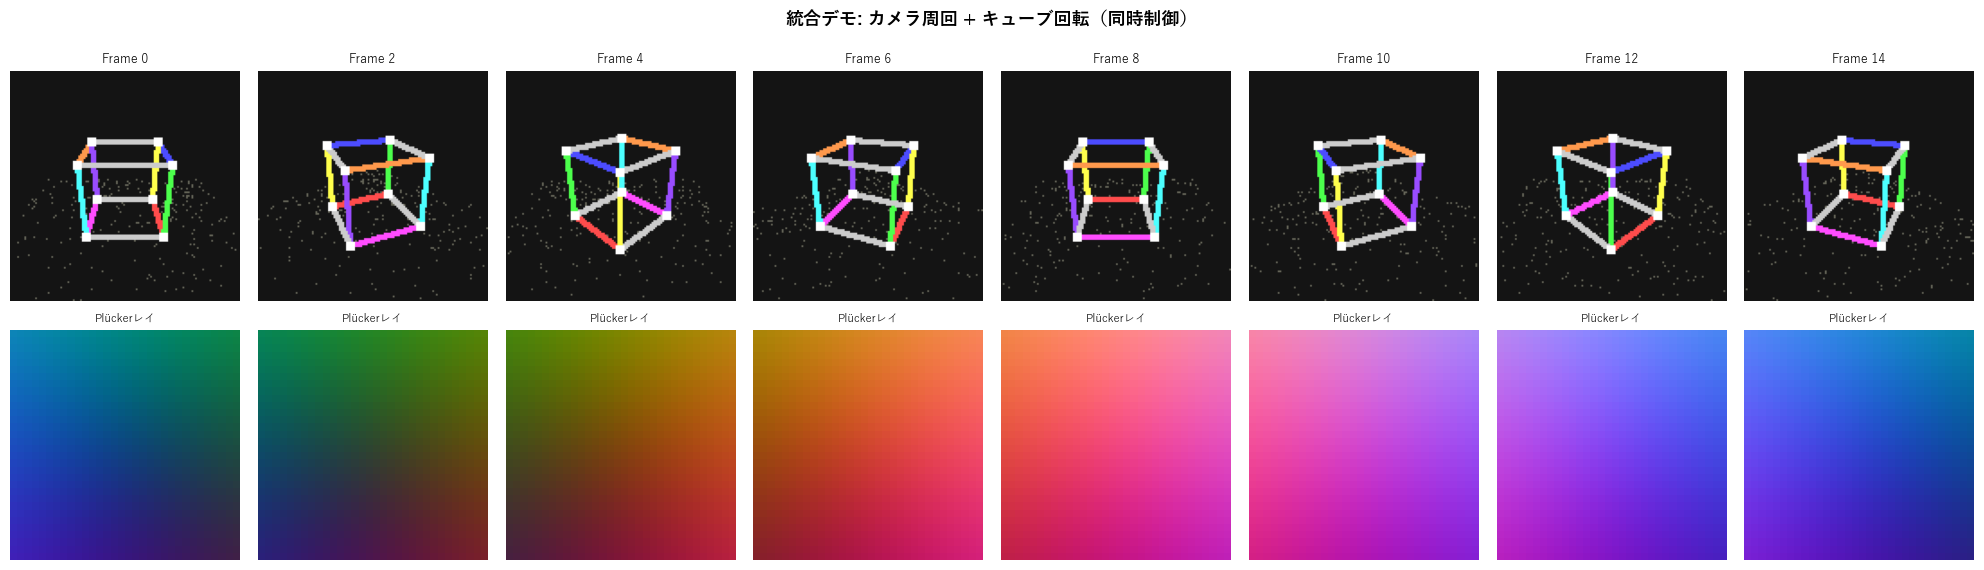

上段: カメラが周回しつつキューブも回転する統合シーン
下段: 各フレームのPlückerレイ方向（カメラ姿勢を反映）

このように、カメラ運動と物体運動を分離して制御することで、
3D整合的な動画生成が可能になります。


In [19]:
# ============================================================
# 統合デモ：カメラ運動 + 物体運動の同時制御
# ============================================================

def combined_camera_object_demo():
    """カメラが周回しつつ、物体も回転する統合シーン"""
    num_frames = 16
    image_size = (128, 128)
    H, W = image_size
    target = np.array([0, 0, 0])
    fov = 60.0
    
    vertices, edges, faces = create_cube_vertices()
    
    # シーン内の追加要素（静止点群 — 地面）
    np.random.seed(77)
    ground_n = 300
    ground_pts = np.column_stack([
        np.random.uniform(-3, 3, ground_n),
        np.full(ground_n, -1.2),
        np.random.uniform(-3, 3, ground_n),
    ])
    ground_colors = np.tile([0.4, 0.4, 0.35], (ground_n, 1))
    
    frames_combined = np.zeros((num_frames, H, W, 3))
    
    for f_idx in range(num_frames):
        # --- カメラ運動: 軌道 ---
        cam_angle = 2 * np.pi * f_idx / num_frames
        cam_pos = np.array([
            4.0 * np.cos(cam_angle),
            2.0,
            4.0 * np.sin(cam_angle)
        ])
        
        # --- 物体運動: キューブ回転 ---
        obj_angle = 2 * np.pi * f_idx / num_frames * 1.5  # カメラより速く回転
        R_obj = rotation_matrix_y(obj_angle)
        rotated_verts = (R_obj @ vertices.T).T
        
        # 背景描画
        frame = np.ones((H, W, 3)) * 0.08
        
        # 地面の描画
        uv_g, depth_g, vis_g = project_points(ground_pts, cam_pos, target, image_size, fov)
        for i in np.where(vis_g)[0]:
            u_p = int(round(uv_g[i, 0]))
            v_p = int(round(uv_g[i, 1]))
            if 0 <= v_p < H and 0 <= u_p < W:
                frame[v_p, u_p] = ground_colors[i]
        
        # キューブの描画
        uv_c, depth_c, vis_c = project_points(rotated_verts, cam_pos, target, image_size, fov)
        cube_render = render_wireframe_cube(uv_c, edges, vis_c, image_size)
        
        # 合成（キューブを前景として上書き）
        mask = np.any(cube_render > 0.1, axis=-1)
        frame[mask] = cube_render[mask]
        
        frames_combined[f_idx] = frame
    
    # --- 表示 ---
    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    
    for j in range(8):
        f_idx = j * 2
        axes[0, j].imshow(np.clip(frames_combined[f_idx], 0, 1))
        axes[0, j].set_title(f'Frame {f_idx}', fontsize=9)
        axes[0, j].axis('off')
        
        # Plücker direction
        cam_angle = 2 * np.pi * f_idx / num_frames
        cam_pos = np.array([4 * np.cos(cam_angle), 2, 4 * np.sin(cam_angle)])
        plucker = compute_plucker_rays(cam_pos, target, (32, 32), fov)
        d_rgb = (plucker[:, :, 3:] + 1) / 2
        axes[1, j].imshow(np.clip(d_rgb, 0, 1))
        axes[1, j].set_title('Plückerレイ', fontsize=8)
        axes[1, j].axis('off')
    
    plt.suptitle('統合デモ: カメラ周回 + キューブ回転（同時制御）',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("上段: カメラが周回しつつキューブも回転する統合シーン")
    print("下段: 各フレームのPlückerレイ方向（カメラ姿勢を反映）")
    print()
    print("このように、カメラ運動と物体運動を分離して制御することで、")
    print("3D整合的な動画生成が可能になります。")

combined_camera_object_demo()

<a id="summary"></a>
## 9. まとめと自己評価クイズ

### 🎯 このノートブックで学んだこと

**カメラ運動と物体運動の分離**
- カメラ運動: 全ピクセルが幾何学的法則に従って一貫的に動く
- 物体運動: 特定領域のみが局所的に動く
- 分離により、ユーザー制御性と3D整合性が向上する

**Plücker ray座標**
- 6次元表現 $(\mathbf{m}, \mathbf{d}) = (\mathbf{o} \times \mathbf{d}, \mathbf{d})$
- Grassmann条件: $\mathbf{d} \cdot \mathbf{m} = 0$
- CameraCtrlなどの動画生成AIでカメラ条件付けに使用

**実装**
- `compute_plucker_rays`: カメラ姿勢からPlücker座標を計算
- `generate_camera_motion_frames`: 軌道カメラのレンダリング
- 回転キューブ: 3D→2D投影によるフレーム列合成

**オプティカルフロー**
- カメラ運動 → 全体的・構造的なフローパターン
- 物体運動 → 局所的なフローパターン

### ⚠️ よくあるエラー

#### エラー #1: Plücker座標の順序間違い
```python
# ❌ 間違い: (direction, moment)
plucker = np.concatenate([direction, moment], axis=-1)

# ✅ 正解: (moment, direction) が一般的な慣習
plucker = np.concatenate([moment, direction], axis=-1)
```

#### エラー #2: 画像座標のY軸方向
```python
# ❌ 間違い: 画像座標は下向きなのに上向きとして計算
rays_cam_y = vv  # 上向き

# ✅ 正解: 画像座標は下向きなので反転
rays_cam_y = -vv  # 画像座標系に合わせて反転
```

#### エラー #3: Look-at行列でupベクトルが前方と平行
```python
# ❌ カメラが真下を向くとき up=(0,1,0) だと外積がゼロに
forward = np.array([0, -1, 0])
right = np.cross(forward, np.array([0, 1, 0]))  # = [0, 0, 0] !

# ✅ 特殊ケースを処理
if np.linalg.norm(right) < 1e-8:
    up = np.array([0, 0, 1])  # 代替upベクトル
    right = np.cross(forward, up)
```

---

## 🎓 自己評価クイズ

### Q1: カメラ運動と物体運動のオプティカルフローの違いは？

<details>
<summary>💡 答えを見る</summary>

**答え**: 
- **カメラ運動**: 全ピクセルに対してフローが発生し、幾何学的に構造化されたパターン（並進→均一、回転→渦巻き、前進→放射状）を示す
- **物体運動**: 動いている物体の領域のみにフローが発生し、背景は静止（フローゼロ）

この違いにより、フローパターンからカメラ運動と物体運動を分離することが理論的に可能です。

</details>

---

### Q2: Plücker座標の6次元表現 $(\mathbf{m}, \mathbf{d})$ において、モーメント $\mathbf{m}$ の幾何学的意味は？

<details>
<summary>💡 答えを見る</summary>

**答え**: モーメント $\mathbf{m} = \mathbf{o} \times \mathbf{d}$ のノルム $\|\mathbf{m}\|$ は、原点からレイまでの最短距離に比例します（$\|\mathbf{d}\| = 1$ のとき等しい）。

また、モーメントはレイの「位置」情報をエンコードしており、同じ方向を向くレイでも異なる位置にあれば異なるモーメントを持ちます。Grassmann条件 $\mathbf{d} \cdot \mathbf{m} = 0$ が常に成り立ちます。

</details>

---

### Q3: CameraCtrlがカメラ姿勢をPlücker座標で表現する利点は？

<details>
<summary>💡 答えを見る</summary>

**答え**:
1. **ピクセルレベルの精密さ**: 各ピクセルに6次元のカメラ情報を与えるため、画像内の位置に応じた正確な3D変化を条件付けできる
2. **幾何学的一貫性**: Plücker座標は3D幾何学の法則に基づいた表現なので、生成画像の3D整合性が保たれやすい
3. **連続性**: カメラが滑らかに動くとPlücker座標も滑らかに変化するため、フレーム間の時間的整合性にも寄与する

</details>

---

### Q4: 回転行列 $R$ が直交行列である（$R^T R = I$, $\det(R) = 1$）ことの実用的意義は？

<details>
<summary>💡 答えを見る</summary>

**答え**:
- **長さの保存**: 回転しても物体の大きさが変わらない（歪みが生じない）
- **可逆性**: $R^{-1} = R^T$ なので、逆変換が容易（転置するだけ）
- **合成の安定性**: 複数の回転の積も直交行列になるため、フレーム間の累積回転が安定

動画生成では、多数のフレームにわたって回転を累積するため、数値的安定性が重要です。

</details>

---

### Q5: 動画生成AIでカメラ運動と物体運動を分離する実用的なメリットを3つ挙げてください。

<details>
<summary>💡 答えを見る</summary>

**答え**:
1. **ユーザー制御性の向上**: 「カメラだけ動かして物体は静止」「物体だけ動かしてカメラは固定」といった直感的な操作が可能
2. **3D整合性の保証**: カメラ運動は厳密な幾何学的制約（エピポーラ幾何など）に従うため、分離することで正確な視点変化を保証できる
3. **学習効率**: 混合された動きを一度に学習するより、分離した信号を個別に学習する方が容易で、少ないデータでも高品質な結果を得やすい

</details>

---

### ✅ 学習チェックリスト

- [ ] カメラ運動と物体運動の概念的分離を図で説明できる
- [ ] Plücker ray座標の6次元表現を理解し、Grassmann条件を検証できる
- [ ] `compute_plucker_rays` の実装を読んで各ステップの意味を説明できる
- [ ] オプティカルフローのパターンからカメラ運動か物体運動かを判別できる
- [ ] 3Dワイヤーフレームの回転・投影の処理フローを実装できる
- [ ] CameraCtrlにおけるPlücker座標の役割を説明できる

---

**次のステップ**: Notebook 134 では、Diffusion Transformerベースの動画生成モデルにおける
3D制御の応用を学びます！